# Task 1A — Exploratory Data Analysis

The dataset is in **long format**: each row is a single (user, timestamp, variable, value) observation.  
Before any modelling, we must understand the temporal structure — because **the goal is to predict next-day mood** from the current day's sensor signals, and that prediction depends entirely on how mood is structured in time.

Key questions:
1. How many users / variables / records?
2. How many days per user, and are they balanced?
3. How many readings per variable per user-day?
4. Are there temporal gaps (missing days) in each user's series?
5. What are the value ranges, and are there obvious outliers?

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.utils import save_figure

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
df = pd.read_csv('../data/raw/dataset_mood_smartphone.csv')
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date
df = df.drop(columns=['Unnamed: 0'])

print(f'Total rows : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Null values: {df.isnull().sum().to_dict()}')
df.head(10)

Total rows : 376,912
Columns    : ['id', 'time', 'variable', 'value', 'date']
Null values: {'id': 0, 'time': 0, 'variable': 0, 'value': 202, 'date': 0}


,id,time,variable,value,date
0,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26
1,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26
2,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26
3,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26
4,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27
5,AS14.01,2014-02-27 12:00:00,mood,6.0,2014-02-27
6,AS14.01,2014-02-27 15:00:00,mood,7.0,2014-02-27
7,AS14.01,2014-03-21 09:00:00,mood,6.0,2014-03-21
8,AS14.01,2014-03-21 11:00:00,mood,6.0,2014-03-21
9,AS14.01,2014-03-21 15:00:00,mood,7.0,2014-03-21


**The dataset is in long format** — each row encodes a single observation: one user, one timestamp, one variable, one value. This is a natural format for sensor logging, but it is not suitable for machine learning directly.

To train a model, we need **one row per prediction unit** (a user-day), with each variable as a separate column. This is called **wide format**. The conversion requires:
1. Choosing how to aggregate multiple readings of the same variable into a single daily value (e.g. mean for mood, sum for screen time)
2. Handling days where a variable has no record at all (implicit zeros for app usage, NaN for mood)

We perform this pivot in cell 7 before any modelling or correlation analysis.

## 2. Dataset overview

Summary of variables, record counts, and value ranges across the dataset.

In [3]:
n_users = df['id'].nunique()
variables = sorted(df['variable'].dropna().unique().tolist())

base_vars = [v for v in variables if not v.startswith('appCat.')]
appcat_vars = [v for v in variables if v.startswith('appCat.')]

print(f'Users     : {n_users}')
print(f'Variables : {len(variables)}')
print()
print('Variables (alphabetical):')
for i, v in enumerate(variables, start=1):
    print(f'  {i:2d}. {v}')

print()
print(f'Non-app variables ({len(base_vars)}): {", ".join(base_vars)}')
print(f'appCat variables ({len(appcat_vars)}): {", ".join(appcat_vars)}')

Users     : 27
Variables : 19

Variables (alphabetical):
   1. activity
   2. appCat.builtin
   3. appCat.communication
   4. appCat.entertainment
   5. appCat.finance
   6. appCat.game
   7. appCat.office
   8. appCat.other
   9. appCat.social
  10. appCat.travel
  11. appCat.unknown
  12. appCat.utilities
  13. appCat.weather
  14. call
  15. circumplex.arousal
  16. circumplex.valence
  17. mood
  18. screen
  19. sms

Non-app variables (7): activity, call, circumplex.arousal, circumplex.valence, mood, screen, sms
appCat variables (12): appCat.builtin, appCat.communication, appCat.entertainment, appCat.finance, appCat.game, appCat.office, appCat.other, appCat.social, appCat.travel, appCat.unknown, appCat.utilities, appCat.weather


In [4]:
# Records per variable
rec_per_var = df.groupby('variable').size().sort_values(ascending=False).rename('n_records')

# Value statistics per variable
stats = df.groupby('variable')['value'].agg(['min', 'max', 'mean', 'std']).round(3)
stats.columns = ['min', 'max', 'mean', 'std']

summary = pd.concat([rec_per_var, stats], axis=1)
summary

,n_records,min,max,mean,std
variable,,,,,
screen,96578,0.035,9867.007,75.335,253.822
appCat.builtin,91288,-82798.871,33960.246,18.538,415.989
appCat.communication,74276,0.006,9830.777,43.344,128.913
appCat.entertainment,27125,-0.011,32148.677,37.576,262.960
activity,22965,0.000,1.000,0.116,0.187
appCat.social,19145,0.094,30000.906,72.402,261.552
appCat.other,7650,0.014,3892.038,25.811,112.781
circumplex.valence,5643,-2.000,2.000,0.688,0.671
circumplex.arousal,5643,-2.000,2.000,-0.099,1.052


**Variable statistics and record counts — key observations:**

- `screen` and `appCat.builtin` dominate the record count: logged at a finer time granularity (per session, not per day), while `mood`, `circumplex.*`, `call`, and `sms` are event-based and appear far less frequently
- `call` and `sms` are **event indicators**: each row = one call or SMS event, so they can appear multiple times per day
- This asymmetry drives the aggregation policy: **sum** for screen and appCat (total seconds/events per day), **mean** for mood and circumplex (average of self-reports)
- `appCat.builtin` has a **minimum of −82,798 seconds** — a clear sensor error to fix in Task 1B; `appCat.entertainment` has a small negative value too
- Several `appCat.*` variables have very large max values (tens of thousands of seconds per day), which may need log-transformation
- `mood` (1–10) and `circumplex.*` (−2 to +2) are within their expected ranges
- The 202 explicit `NaN` values are **not random**: they come from missing entries in `circumplex.arousal` and `circumplex.valence` — treat as missing self-reports, not zeros

Saved: figures/1a_records_per_variable.png


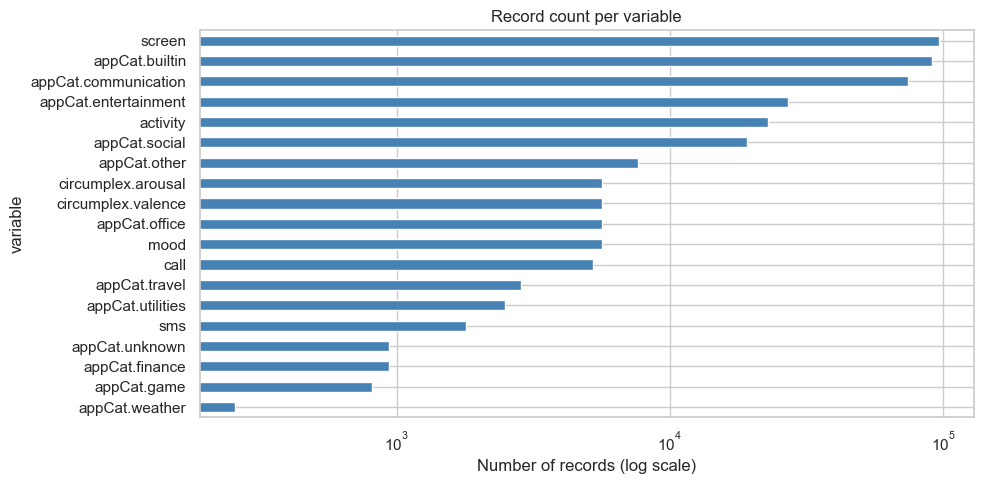

In [5]:
# --- Records per variable (log scale) ---
fig, ax = plt.subplots(figsize=(10, 5))
rec_per_var.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of records (log scale)')
ax.set_title('Record count per variable')
ax.set_xscale('log')
plt.tight_layout()
save_figure('1a_records_per_variable.png')
plt.show()

## 3. Temporal structure — days per user

In [6]:
# User-level coverage: raw volume vs normalized monitoring intensity
user_coverage = (df.groupby('id')
                 .agg(total_data_collected=('value', 'size'),
                      first_day=('date', 'min'),
                      last_day=('date', 'max'),
                      recorded_days=('date', 'nunique'))
                 .sort_values('total_data_collected', ascending=False))

user_coverage['span_days'] = (pd.to_datetime(user_coverage['last_day']) -
                              pd.to_datetime(user_coverage['first_day'])).dt.days + 1
user_coverage['missing_days'] = user_coverage['span_days'] - user_coverage['recorded_days']
user_coverage['missing_pct'] = (user_coverage['missing_days'] / user_coverage['span_days'] * 100).round(1)
user_coverage['data_per_recorded_day'] = (user_coverage['total_data_collected'] / user_coverage['recorded_days']).round(1)
user_coverage['data_per_span_day'] = (user_coverage['total_data_collected'] / user_coverage['span_days']).round(1)

print('Data Collection per user (raw volume):')
display(user_coverage[['recorded_days', 'span_days', 'missing_days', 'missing_pct', 'total_data_collected', 'data_per_recorded_day', 'data_per_span_day']])

Data Collection per user (raw volume):


,recorded_days,span_days,missing_days,missing_pct,total_data_collected,data_per_recorded_day,data_per_span_day
id,,,,,,,
AS14.01,72,78,6,7.7,21999,305.5,282.0
AS14.23,63,77,14,18.2,21852,346.9,283.8
AS14.13,72,77,5,6.5,19592,272.1,254.4
AS14.28,58,81,23,28.4,19276,332.3,238.0
AS14.06,74,81,7,8.6,18092,244.5,223.4
AS14.29,73,88,15,17.0,17499,239.7,198.9
AS14.12,67,76,9,11.8,17311,258.4,227.8
AS14.30,70,78,8,10.3,17279,246.8,221.5
AS14.26,100,103,3,2.9,16403,164.0,159.3


In [7]:
print('\nSummary of imbalance across users:')
print(user_coverage[['total_data_collected', 'data_per_recorded_day', 'missing_pct']].describe().round(2))
print(f"\nRaw data ratio max/min: {user_coverage['total_data_collected'].max() / user_coverage['total_data_collected'].min():.2f}x")
print(f"Normalized ratio (data_per_recorded_day) max/min: {user_coverage['data_per_recorded_day'].max() / user_coverage['data_per_recorded_day'].min():.2f}x")


Summary of imbalance across users:
       total_data_collected  data_per_recorded_day  missing_pct
count                 27.00                  27.00        27.00
mean               13959.70                 196.20         8.27
std                 5118.45                  82.60         6.52
min                 2848.00                  36.10         0.00
25%                11295.00                 152.85         3.35
50%                14581.00                 187.30         7.70
75%                17295.00                 245.65        11.05
max                21999.00                 346.90        28.40

Raw data ratio max/min: 7.72x
Normalized ratio (data_per_recorded_day) max/min: 9.61x


**User coverage table**

- `recorded_days`: days with at least one observation
- `span_days`: calendar days from first to last observation
- `missing_days` / `missing_pct`: gaps inside the user's active window
- `total_data_collected`: total records for that user
- `data_per_recorded_day`: average records on days the user was active (independent of study length)
- `data_per_span_day`: average records across the full span (including missing days)

We use `data_per_recorded_day` as the **normalised measure** because users were monitored for different lengths of time. A user monitored for 100 days will naturally have more total records than one monitored for 50 days — even if they were equally active. Normalising by recorded days removes this bias and lets us compare *how intensively* each user logged data, regardless of how long they participated.

In [8]:
# Monthly monitoring coverage table
user_days = df[['id', 'date']].drop_duplicates().copy()
user_days['month'] = pd.to_datetime(user_days['date']).dt.to_period('M')

monthly_coverage = (
    user_days.groupby('month')
    .agg(active_users=('id', 'nunique'),
         observed_user_days=('date', 'size'))
    .join(
        df.assign(month=pd.to_datetime(df['date']).dt.to_period('M'))
          .groupby('month').size().rename('total_collected_data')
    )
)
monthly_coverage['data_per_user_day'] = (
    monthly_coverage['total_collected_data'] / monthly_coverage['observed_user_days']
).round(1)
monthly_coverage.index.name = 'month'
display(monthly_coverage.reset_index())

,month,active_users,observed_user_days,total_collected_data,data_per_user_day
0,2014-02,25,240,1102,4.6
1,2014-03,26,668,73620,110.2
2,2014-04,27,797,233483,293.0
3,2014-05,26,259,66808,257.9
4,2014-06,1,9,1899,211.0


Saved: figures/1a_monthly_monitoring_coverage.png


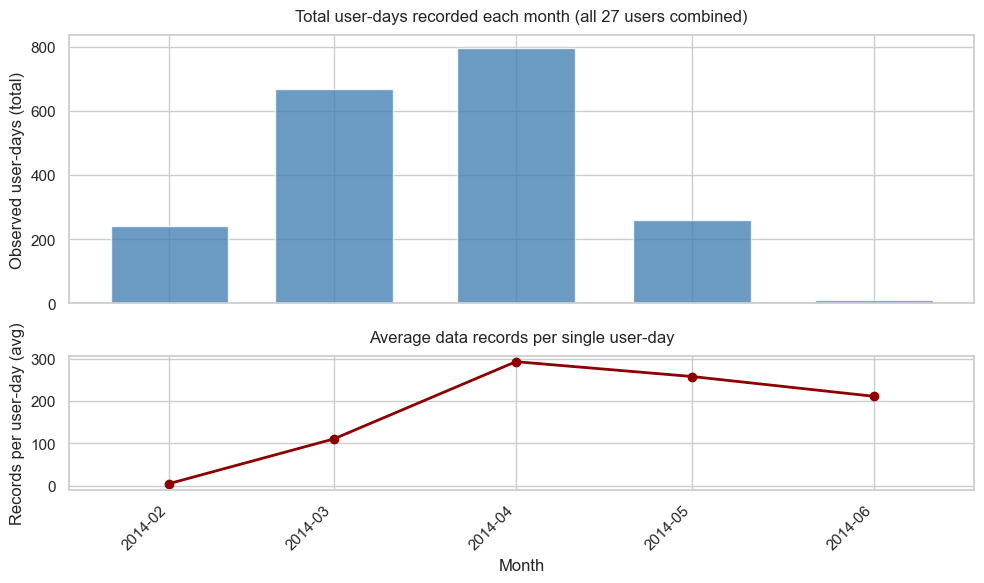

In [9]:
# Plot: monthly monitoring coverage profile
monthly_plot = monthly_coverage.copy()
monthly_plot.index = monthly_plot.index.to_timestamp()   # Period → datetime

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# ── Top: total observed user-days across ALL users combined ──────────────────
ax1.bar(monthly_plot.index, monthly_plot["observed_user_days"], width=20,
        color="steelblue", alpha=0.80)
ax1.set_ylabel("Observed user-days (total)")
ax1.set_title(f"Total user-days recorded each month (all {n_users} users combined)", pad=10)

# ── Bottom: data density per single user-day ─────────────────────────────────
ax2.plot(monthly_plot.index, monthly_plot["data_per_user_day"], marker="o",
         color="darkred", linewidth=2)
ax2.set_ylabel("Records per user-day (avg)")
ax2.set_xlabel("Month")
ax2.set_title("Average data records per single user-day", pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

fig.tight_layout()
save_figure("1a_monthly_monitoring_coverage.png")
plt.show()

**Findings — monthly monitoring coverage**

The study was most active in **March and April 2014**. After April, most participants dropped out — by June almost nobody was left.

**Why does the top chart drop sharply after April, but not the bottom one?**

The two panels measure different things:
- **Top (bars):** total days of data across *all* participants combined — this goes down when people drop out.
- **Bottom (line):** average records logged per day, for participants who were *still active* — this stays stable because the people who stayed were just as engaged as before.

In other words: after April, many users simply left the study. But whoever remained kept using the app at the same rate. The drop is about **fewer people**, not **less engagement**.

**February is a special case** and is dissected in the dedicated analysis just below — the picture is more nuanced than a uniform "setup phase".

In [10]:
# --- February deep-dive: is the Feb gap uniform, and is it per-user or calendar? ---
# (1) Records per user-day, BY VARIABLE, Feb vs Apr
df['month_period'] = pd.to_datetime(df['date']).dt.to_period('M')
user_days_month = df[['id', 'date', 'month_period']].drop_duplicates().groupby('month_period').size()
by_var = df.groupby(['variable', 'month_period']).size().unstack('month_period').fillna(0)
for m in by_var.columns:
    by_var[m] = by_var[m] / user_days_month[m]
feb_apr = by_var[[pd.Period('2014-02'), pd.Period('2014-04')]].copy()
feb_apr.columns = ['feb_per_user_day', 'apr_per_user_day']
feb_apr['feb_vs_apr'] = (feb_apr['feb_per_user_day'] / feb_apr['apr_per_user_day']).round(3)
feb_apr = feb_apr.round(2).sort_values('feb_vs_apr')
print('Per-variable logging intensity, Feb vs Apr (records per user-day):')
display(feb_apr)

# (2) Calendar-absolute vs user-relative test: split users by enrollment month
first_day = df.groupby('id')['date'].min()
df['_day_since_start'] = (pd.to_datetime(df['date']) -
                          pd.to_datetime(df['id'].map(first_day))).dt.days
early = first_day[pd.to_datetime(first_day) < '2014-03-01'].index
late  = first_day[pd.to_datetime(first_day) >= '2014-03-01'].index

def avg_by_day(ids, n=15):
    sub = df[df['id'].isin(ids) & (df['_day_since_start'] <= n)]
    return (sub.groupby(['id', '_day_since_start']).size()
               .groupby('_day_since_start').mean().round(1))

ramp = pd.DataFrame({
    f'early_users_feb_start (n={len(early)})': avg_by_day(early),
    f'late_users_mar+_start (n={len(late)})':  avg_by_day(late)
}).fillna(0)
print('\nAvg records per user on day N since personal enrollment:')
display(ramp)
df.drop(columns=['month_period', '_day_since_start'], inplace=True)

Per-variable logging intensity, Feb vs Apr (records per user-day):


,feb_per_user_day,apr_per_user_day,feb_vs_apr
variable,,,
activity,0.00,18.11,0.00
appCat.weather,0.00,0.19,0.00
appCat.utilities,0.00,2.14,0.00
appCat.unknown,0.00,0.62,0.00
screen,0.00,76.37,0.00
appCat.social,0.00,14.86,0.00
appCat.other,0.00,5.86,0.00
appCat.travel,0.00,2.32,0.00
appCat.game,0.00,0.68,0.00



Avg records per user on day N since personal enrollment:


,early_users_feb_start (n=25),late_users_mar+_start (n=2)
_day_since_start,,
0,3.9,2.0
1,3.6,46.0
2,6.1,274.5
3,4.3,189.0
4,5.0,167.5
5,6.1,239.0
6,3.4,459.0
7,4.2,363.5
8,5.2,429.0


**Findings — February is unusable for training, but not for the reason you might expect**

- **The Feb gap is not uniform across variables.** Three distinct groups:
  - *Group A (13 vars: `screen`, `activity`, all `appCat.*`):* **zero records** in February — the app-based active tracking was not yet running.
  - *Group B (`mood`, `circumplex.valence`, `circumplex.arousal`):* near-zero (~0.03/user-day vs 4.28 in April) — users were not yet completing the self-report.
  - *Group C (`call`, `sms`):* **normal or higher** in February than in April (ratios 1.33 and 1.67) — these are read retroactively from the phone's OS log at install time.

- **The ramp-up is calendar-absolute, not per-user.** The 2 users who joined in March/April reach full logging capacity (~275 records) by **day 2** of their personal timeline, while early users stay at ~4–6 records/day for 3 weeks. So the issue is study-wide infrastructure, not individual onboarding — no need to trim "first N days per user".

- **Policy for Task 1B/1C — exclude February from training.** Not because sensors are unreliable, but because the **`mood` target is virtually absent** (0.03/user-day → effectively no computable next-day mood). Call/SMS data exists but without a target there is nothing to train on for those days.

**Key finding:** Users are *not* balanced. Active days range from **50 to 101**. Up to **28.4% of days are missing** (AS14.28), which must be handled carefully in Task 1B before building the sliding window.

Saved: figures/1a_active_missing_days.png


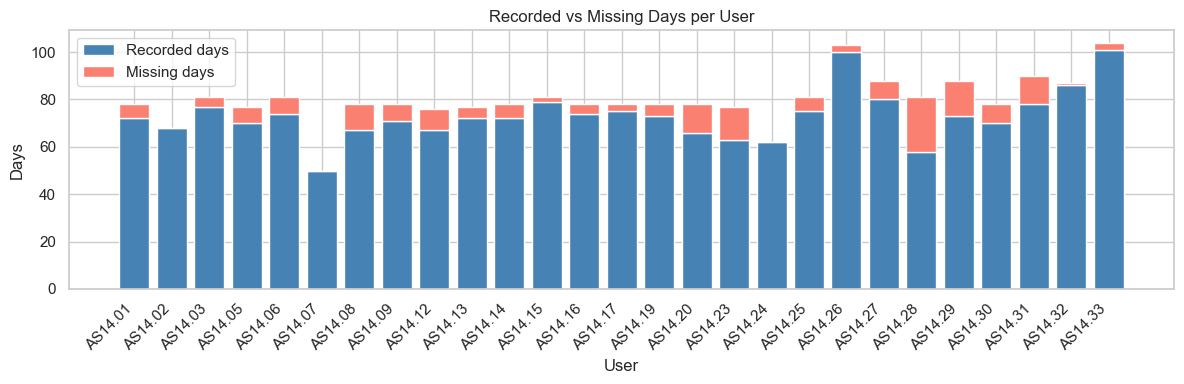

In [11]:
# --- Plot 2: Recorded days and missing days per user ---
fig, ax = plt.subplots(figsize=(12, 4))
uc = user_coverage.sort_index()
users = uc.index
ax.bar(users, uc['recorded_days'], label='Recorded days', color='steelblue')
ax.bar(users, uc['missing_days'], bottom=uc['recorded_days'], label='Missing days', color='salmon')
ax.set_xlabel('User')
ax.set_ylabel('Days')
ax.set_title('Recorded vs Missing Days per User')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_active_missing_days.png')
plt.show()

**Findings — active vs missing days:**
- The dataset is **unbalanced**: active days span 50–101 per user, so a global model sees more data from some users than others
- Up to 28.4 % of calendar days are missing for one user — temporal gaps are not rare exceptions but a structural feature of the data
- Any sliding-window feature engineering must check for and respect these gaps (a window crossing a gap is invalid)

## 4. Mood readings per user-day (is mood measured once or many times?)

In [12]:
mood_df = df[df['variable'] == 'mood']
readings_per_day = mood_df.groupby(['id', 'date']).size()

print('Mood readings per user-day:')
print(readings_per_day.describe().round(2))
print()
print('Distribution of reading counts:')
print(readings_per_day.value_counts().sort_index())

Mood readings per user-day:
count    1268.00
mean        4.45
std         0.95
min         1.00
25%         4.00
50%         5.00
75%         5.00
max         6.00
dtype: float64

Distribution of reading counts:
1     25
2     58
3     77
4    290
5    799
6     19
Name: count, dtype: int64


Saved: figures/1a_mood_readings_per_day.png


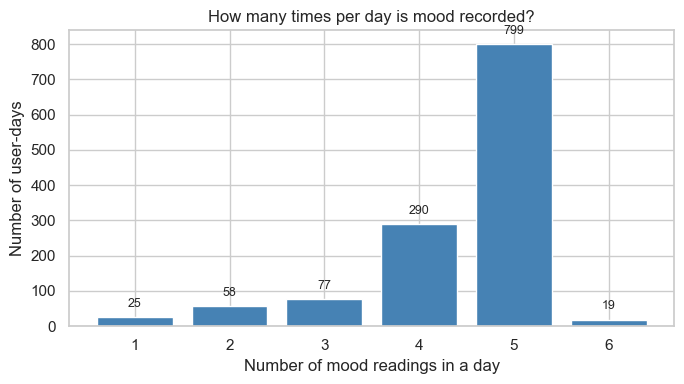

In [13]:
# Plot: distribution of mood readings per user-day
fig, ax = plt.subplots(figsize=(7, 4))
counts = readings_per_day.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of mood readings in a day')
ax.set_ylabel('Number of user-days')
ax.set_title('How many times per day is mood recorded?')
ax.set_xticks(counts.index)
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
save_figure('1a_mood_readings_per_day.png')
plt.show()

**Findings — mood readings per day**

On most days, participants recorded their mood exactly **5 times** (799 out of 1268 user-days), and the vast majority logged 4 or 5 times. The mean is 4.45 with very low spread (std = 0.95).

This suggests the study had a **structured protocol** — participants were prompted to log mood at fixed intervals rather than doing so spontaneously. Days with fewer readings (1–3) likely reflect missed prompts or partial participation.

In [14]:
# Reusable check: readings per user-day for any variable
def readings_per_user_day(df, variable_name):
    var_df = df[df['variable'] == variable_name]
    counts = var_df.groupby(['id', 'date']).size()
    
    print(f'{variable_name} readings per user-day:')
    print(counts.describe().round(2))
    print()
    print('Distribution of reading counts:')
    print(counts.value_counts().sort_index())
    return counts

# Example: change variable_name to inspect any variable
variable_name = 'screen'
_ = readings_per_user_day(df, variable_name)

screen readings per user-day:
count    1207.00
mean       80.01
std        54.18
min         1.00
25%        38.00
50%        75.00
75%       109.00
max       374.00
dtype: float64

Distribution of reading counts:
1      13
2       8
3      18
4      13
5       9
       ..
278     1
285     1
313     1
318     1
374     1
Name: count, Length: 216, dtype: int64


Saved: figures/1a_screen_readings_per_day.png


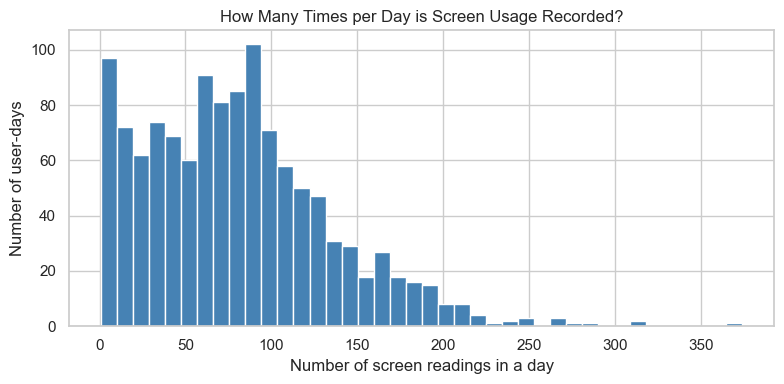

In [15]:
# --- Histogram: screen readings per user-day ---
screen_counts = df[df['variable'] == 'screen'].groupby(['id', 'date']).size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(screen_counts, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of screen readings in a day')
ax.set_ylabel('Number of user-days')
ax.set_title('How Many Times per Day is Screen Usage Recorded?')
plt.tight_layout()
save_figure('1a_screen_readings_per_day.png')
plt.show()


**Findings — screen readings per day**

Unlike mood, screen usage is logged **continuously** — every time the screen turns on or off. As a result, the distribution is spread across a wide range (1–374 readings/day) with high variability (std = 54).

The distribution is **right-skewed**: most user-days cluster between 38 and 109 readings (IQR), but a long tail extends to 300+, representing days of very heavy phone use. The median (75) is well below the mean (80), confirming the skew.

There is no fixed protocol here — screen count is a behavioural signal that varies naturally across users and days.

## 5. Target variable — mood distribution

The target for all models is the **next-day mood** (daily mean of all mood readings). Understanding its distribution determines the classification threshold and reveals class imbalance.

Saved: figures/1a_mood_distribution.png


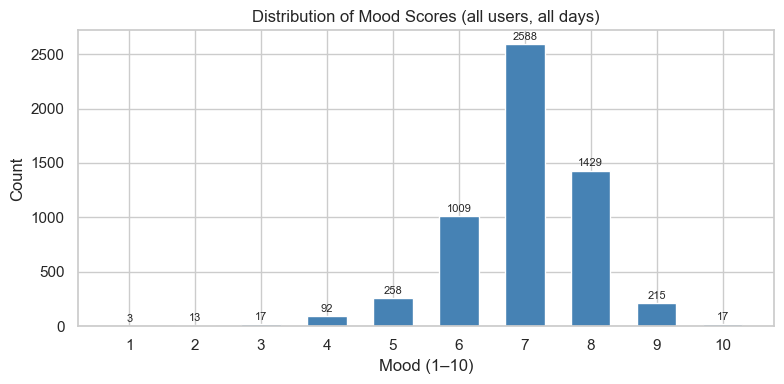

In [16]:
# --- Plot 1: Distribution of mood scores ---
mood_counts = mood_df['value'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(mood_counts.index, mood_counts.values, color='steelblue', width=0.6)

# Label every bar with its count
for bar, count in zip(bars, mood_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=8)

ax.set_title('Distribution of Mood Scores (all users, all days)')
ax.set_xlabel('Mood (1–10)')
ax.set_ylabel('Count')
ax.set_xticks(mood_counts.index)
plt.tight_layout()
save_figure('1a_mood_distribution.png')
plt.show()


In [17]:
# Mood distribution statistics — skewness, kurtosis, percentiles
from scipy.stats import skew, kurtosis

mood_vals = mood_df['value'].dropna()
print(f'Mood descriptive statistics (all readings, n={len(mood_vals):,}):')
print(f'  Mean   : {mood_vals.mean():.3f}')
print(f'  Median : {mood_vals.median():.3f}')
print(f'  Std    : {mood_vals.std():.3f}')
print(f'  Skew   : {skew(mood_vals):.3f}  (negative = left-skewed / mass toward high values)')
print(f'  Kurt   : {kurtosis(mood_vals):.3f}')
print()
print('Percentiles:')
print(mood_vals.quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).round(2))
print()
# Value counts to see discreteness
print('Value counts (mood is integer-valued):')
print(mood_vals.value_counts().sort_index())

Mood descriptive statistics (all readings, n=5,641):
  Mean   : 6.993
  Median : 7.000
  Std    : 1.033
  Skew   : -0.833  (negative = left-skewed / mass toward high values)
  Kurt   : 2.463

Percentiles:
0.05    5.0
0.10    6.0
0.25    7.0
0.50    7.0
0.75    8.0
0.90    8.0
0.95    8.0
Name: value, dtype: float64

Value counts (mood is integer-valued):
value
1.0        3
2.0       13
3.0       17
4.0       92
5.0      258
6.0     1009
7.0     2588
8.0     1429
9.0      215
10.0      17
Name: count, dtype: int64


**Mood distribution findings:**
- Mood is **left-skewed** (negative skew): most readings cluster around 6–8, with rare very low values — people systematically report positive affect
- This creates a **class imbalance** for binary classification: the "high mood" class will be larger
- The distribution is **discrete** (integer values 1–10)
- Choosing the classification threshold: the **median of the daily means** (not of individual readings) gives equal class sizes by construction — the threshold must be computed on the aggregated target, not on raw self-reports

Saved: figures/1a_mood_timeseries.png


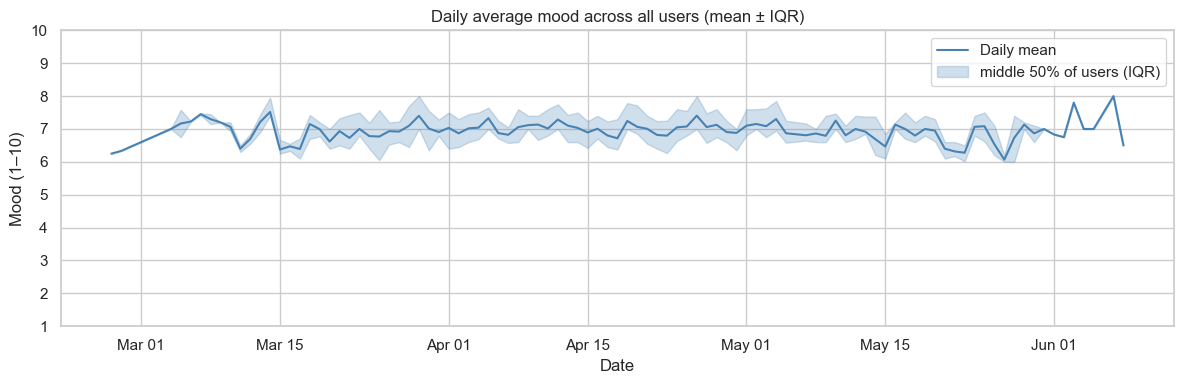

In [18]:
# --- Aggregated daily mood: mean ± IQR across all users ---
daily_mood = mood_df.groupby(["id", "date"])["value"].mean().reset_index()
daily_mood["date"] = pd.to_datetime(daily_mood["date"])

agg = daily_mood.groupby("date")["value"].agg(
    mean="mean",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(agg["date"], agg["mean"], color="steelblue", linewidth=1.5, label="Daily mean")
ax.fill_between(agg["date"], agg["q25"], agg["q75"],
                alpha=0.25, color="steelblue", label="middle 50% of users (IQR)")
ax.set_ylim(1, 10)
ax.set_ylabel("Mood (1–10)")
ax.set_xlabel("Date")
ax.set_title("Daily average mood across all users (mean ± IQR)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
save_figure("1a_mood_timeseries.png")
plt.show()

**Findings — mood trend over time**

The blue line is the **average mood across all active users** on each day. The shaded area shows the **middle 50% of users** — meaning on any given day, half the participants had a mood value within that band.

A narrow band means most users felt similarly that day; a wide band means moods were spread out across the group.

### Classification target — threshold exploration for Task 2A

Task 2A needs a binary label (`high` vs `low` next-day mood), which requires a threshold τ. The obvious candidates both have flaws:

- **Scale midpoint (τ = 5.5)** → ~95% of user-days would be `high`: degenerate.
- **Median of raw integer readings (= 7)** → ~30% of readings are exactly 7, so `>` vs `>=` moves a huge block between classes arbitrarily.

The natural fix is to aggregate to one **daily mean per user-day** and use its median as τ — since means should be continuous, ties should disappear. The plot below checks whether this really happens.

User-days with mood: 1268
Threshold tau = median(daily mean mood) = 7.000
User-days exactly equal to tau: 233 (18.4%)
Class balance with >= tau: high=61.5%, low=38.5%
Class balance with >  tau: high=43.1%, low=56.9%


Saved: figures/1a_mood_threshold_justification.png


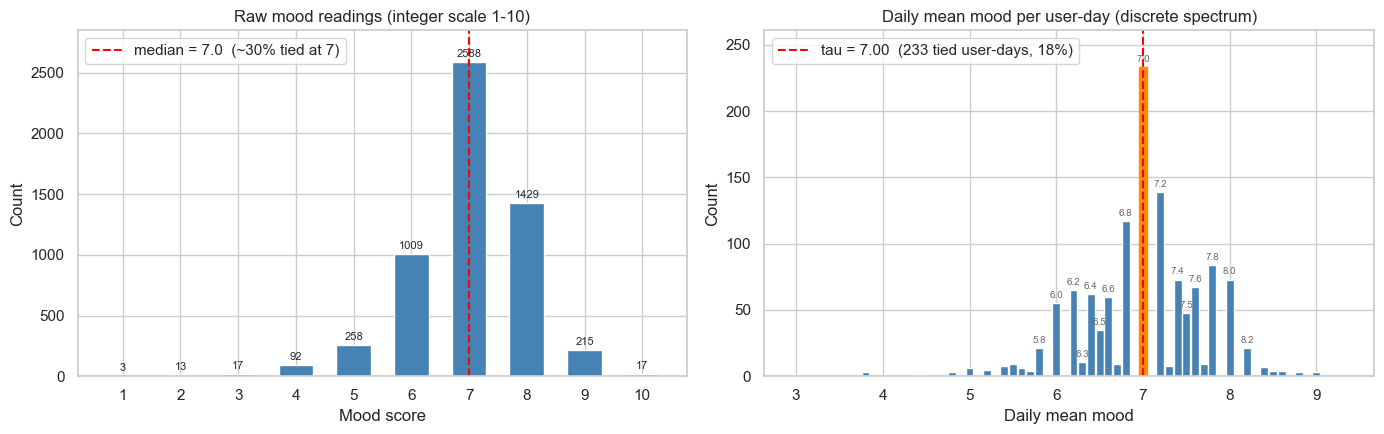

In [19]:
# --- Binary target exploration: raw readings vs daily means ---
daily_mood_mean = (mood_df.groupby(['id', 'date'])['value']
                   .mean().rename('mood_mean').reset_index())

tau = daily_mood_mean['mood_mean'].median()
n_tie_tau = (daily_mood_mean['mood_mean'] == tau).sum()
n_total = len(daily_mood_mean)

bal_ge = (daily_mood_mean['mood_mean'] >= tau).mean()
bal_gt = (daily_mood_mean['mood_mean'] >  tau).mean()

print(f'User-days with mood: {n_total}')
print(f'Threshold tau = median(daily mean mood) = {tau:.3f}')
print(f'User-days exactly equal to tau: {n_tie_tau} ({n_tie_tau/n_total:.1%})')
print(f'Class balance with >= tau: high={bal_ge:.1%}, low={1-bal_ge:.1%}')
print(f'Class balance with >  tau: high={bal_gt:.1%}, low={1-bal_gt:.1%}')

# --- Side-by-side: raw readings vs daily means (discrete values) ---
raw_median = mood_df['value'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: raw integer readings
raw_counts = mood_df['value'].value_counts().sort_index()
bars_left = axes[0].bar(raw_counts.index, raw_counts.values,
                        color='steelblue', width=0.6)
for bar, count in zip(bars_left, raw_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(raw_counts.values) * 0.01,
                 str(count), ha='center', va='bottom', fontsize=8)
axes[0].axvline(raw_median, color='red', linestyle='--', linewidth=1.5,
                label=f'median = {raw_median:.1f}  (~30% tied at 7)')
axes[0].set_title('Raw mood readings (integer scale 1-10)')
axes[0].set_xlabel('Mood score')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(top=max(raw_counts.values) * 1.10)
axes[0].legend()

# Right: daily means as DISCRETE values (not a smoothed histogram)
# Rationale: ~5 integer readings/day produce only rational means (6.8, 7.0, 7.2, ...).
# A continuous histogram hides the spike at 7.0; a bar chart reveals it honestly.
# Round to 1 decimal: keeps the structure (7.0, 6.8, 7.2, ...) while
# merging the close-but-distinct values that 2-decimal rounding would split.
mean_counts = (daily_mood_mean['mood_mean'].round(1)
               .value_counts().sort_index())
bar_width = 0.09  # fits comfortably in the 0.1 grid
bars_right = axes[1].bar(mean_counts.index, mean_counts.values,
                         color='steelblue', width=bar_width)
# Highlight the tau spike
for x, bar in zip(mean_counts.index, bars_right):
    if x == round(tau, 1):
        bar.set_color('darkorange')
for x, bar, count in zip(mean_counts.index, bars_right, mean_counts.values):
    if count >= mean_counts.max() * 0.04:  # label only visible bars
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + mean_counts.max() * 0.01,
                     f'{x:.1f}', ha='center', va='bottom',
                     fontsize=7, color='dimgray')
axes[1].axvline(tau, color='red', linestyle='--', linewidth=1.5,
                label=f'tau = {tau:.2f}  ({n_tie_tau} tied user-days, '
                      f'{n_tie_tau/n_total:.0%})')
axes[1].set_title('Daily mean mood per user-day (discrete spectrum)')
axes[1].set_xlabel('Daily mean mood')
axes[1].set_ylabel('Count')
axes[1].set_ylim(top=mean_counts.max() * 1.12)
axes[1].legend()

plt.tight_layout()
save_figure('1a_mood_threshold_justification.png')
plt.show()

**Findings — threshold on daily mean mood**

- τ = median(daily means) = **7.0 exactly** — same value as the raw median.
- **233 user-days (18%)** still land exactly on τ. Means of ~5 integer readings cluster on rational values (6.8, 7.0, 7.2, …), keeping a visible spike at 7.0.
- Class balance: **61.5 / 38.5** with `>= τ`, **43.1 / 56.9** with `> τ`. Any single threshold leaves a minimum gap of ~14 points.

**Bottom line — the tie problem is reduced (~30% → ~18%), not eliminated, but acceptable.** A 57/43 split is cleanly handled in training with `class_weight='balanced'` and threshold-agnostic metrics (AUC, balanced accuracy). Forcing 50/50 by splitting tied user-days would assign semantically identical points to opposite classes — worse than the imbalance itself. Final decision deferred to **Task 2A**.

## 6. Value distributions and outliers

Saved: figures/1a_value_distributions_apps.png


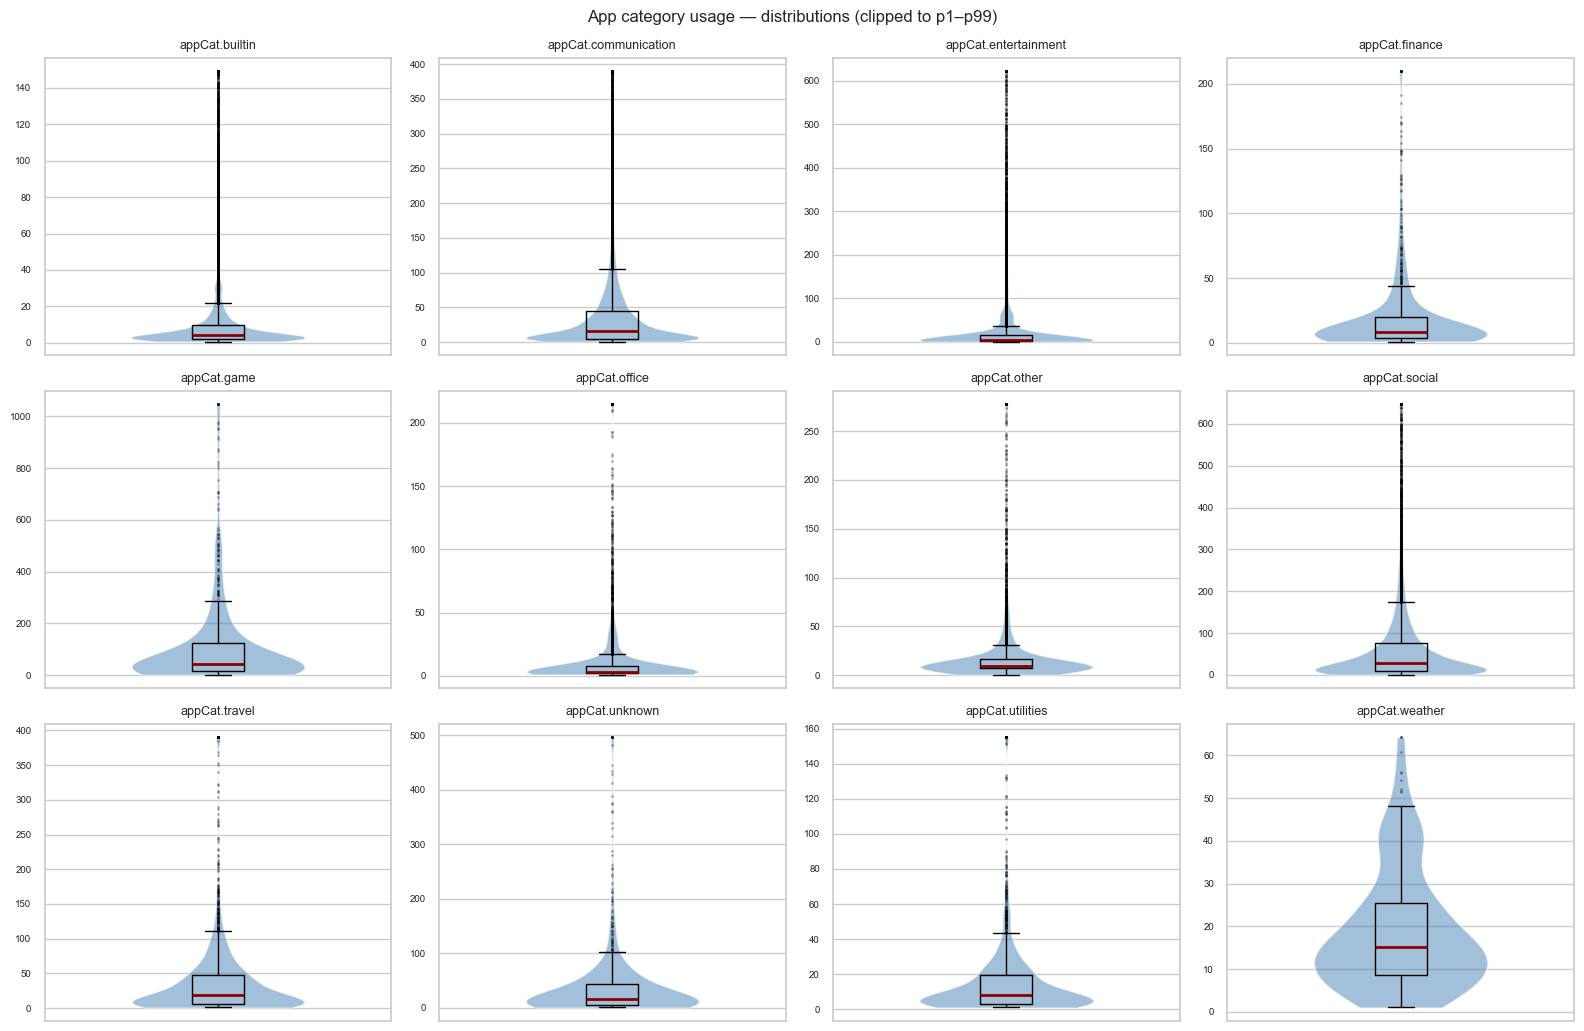

Saved: figures/1a_value_distributions.png


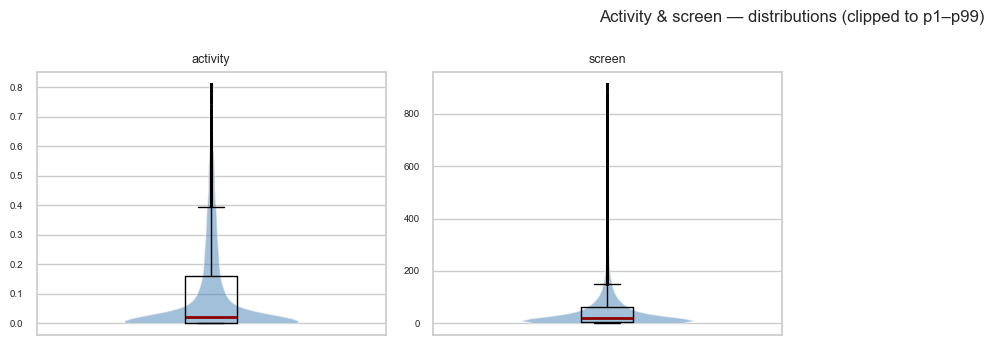

In [20]:
# --- Plot 5: Value distributions — violin + boxplot overlay, split by variable group ---
exclude = ['call', 'sms', 'mood', 'circumplex.arousal', 'circumplex.valence']
plot_df = df[~df['variable'].isin(exclude)]

app_vars   = sorted([v for v in plot_df['variable'].unique() if v.startswith('appCat')])
other_vars = sorted([v for v in plot_df['variable'].unique() if not v.startswith('appCat')])

def plot_group(variables, title, filename):
    n_cols = 4
    n_rows = -(-len(variables) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        var_data = plot_df[plot_df['variable'] == var]['value'].dropna()

        p01, p99 = var_data.quantile(0.01), var_data.quantile(0.99)
        clipped = var_data.clip(p01, p99)

        # Violin plot
        parts = ax.violinplot(clipped, positions=[1], showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor('steelblue')
            pc.set_alpha(0.5)

        # Boxplot overlay
        ax.boxplot(clipped, positions=[1], widths=0.15,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3),
                   boxprops=dict(color='black'),
                   medianprops=dict(color='darkred', linewidth=2),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))

        ax.set_title(var, fontsize=9)
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=7)

    for ax in axes[len(variables):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    save_figure(filename)
    plt.show()

plot_group(app_vars,   'App category usage — distributions (clipped to p1–p99)', '1a_value_distributions_apps.png')
plot_group(other_vars, 'Activity & screen — distributions (clipped to p1–p99)',  '1a_value_distributions.png')


**How to read these plots**

Each subplot combines a **violin plot** and a **boxplot** for one variable:

- **The shape (violin):** wider = more values concentrated there. A violin wide at the bottom and narrow at the top means most observations are low, with a few high ones.
- **The box:** spans the middle 50% of the data (25th to 75th percentile). A small box near zero means most users had near-zero usage on most days.
- **The red line:** median — the value that splits the data exactly in half.
- **The whiskers:** extend to the range of non-extreme values (clipped here at the 1st–99th percentile to keep the plot readable).

**Key finding:** nearly all `appCat.*` variables have the violin and median squeezed near zero, with a long tail upward. This means app usage is **sparse** — on most days, most users do not use a given category at all, but a few days show very high usage. These variables will likely need a log transformation before modelling.

**Findings — value distributions:**
- `appCat.builtin` shows a **severe negative outlier** (min ≈ −82,798 seconds) — a clear sensor error; must be clipped in Task 1B
- `appCat.entertainment` also has a small negative value — same treatment
- `screen` and several `appCat.*` have extreme right tails; plausible but worth log-transforming
- `mood` and `circumplex.*` are within their defined ranges with no hard errors

## 7. Wide-format daily aggregation

> **Note:** The pivot performed here is solely to enable the correlation heatmap below. It is a temporary structure for exploratory visualisation only. The definitive data transformation — including outlier removal, imputation, and feature aggregation — is carried out in Task 1B.

All subsequent analyses require one row per (user, date).
Aggregation should depend on variable meaning:

- `mood`, `circumplex.*`: daily **mean** (average of self-reports)
- `activity`: daily **mean** (normalised score in [0, 1] — averaging is semantically correct)
- `screen`, `appCat.*`: daily **sum** (total time in seconds per day)
- `call`, `sms`: daily **sum** (total number of events per day)

In [21]:
# Recommended daily aggregation policy by variable
variables = sorted(df['variable'].unique())

def choose_daily_agg(var):
    if var in ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']:
        return 'mean'
    else:   # call, sms, screen, appCat.* → sum (count events / total seconds)
        return 'sum'

agg_map = {var: choose_daily_agg(var) for var in variables}
print('Aggregation policy:')
for var, agg in agg_map.items():
    print(f'  {var:35s} → {agg}')

Aggregation policy:
  activity                            → mean
  appCat.builtin                      → sum
  appCat.communication                → sum
  appCat.entertainment                → sum
  appCat.finance                      → sum
  appCat.game                         → sum
  appCat.office                       → sum
  appCat.other                        → sum
  appCat.social                       → sum
  appCat.travel                       → sum
  appCat.unknown                      → sum
  appCat.utilities                    → sum
  appCat.weather                      → sum
  call                                → sum
  circumplex.arousal                  → mean
  circumplex.valence                  → mean
  mood                                → mean
  screen                              → sum
  sms                                 → sum


In [22]:
# Pivot long → wide: one row per (user, date), with variable-specific daily aggregation
if 'agg_map' not in globals():
    variables = sorted(df['variable'].unique())
    
    def choose_daily_agg(var_name):
        if var_name in ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']:
            return 'mean'
        if var_name in ['call', 'sms'] or var_name.startswith('appCat.') or var_name == 'screen':
            return 'sum'
        return 'mean'
    
    agg_map = {v: choose_daily_agg(v) for v in variables}

grouped = df.groupby(['id', 'date', 'variable'])['value']
daily_agg = []
for var, agg_fn in agg_map.items():
    s = getattr(grouped, agg_fn)().xs(var, level='variable').rename(var)
    daily_agg.append(s)

wide = pd.concat(daily_agg, axis=1).reset_index()
wide['date']        = pd.to_datetime(wide['date'])
wide['day_of_week'] = wide['date'].dt.dayofweek   # 0 = Monday, 6 = Sunday

print(f'Wide-format shape: {wide.shape}')
print(f'  Rows = user-days  |  Columns = id, date, {wide.shape[1]-2} variables')
print(f'\nMissing values per column (count):')
print(wide.isnull().sum().sort_values(ascending=False).head(20))

Wide-format shape: (1973, 22)
  Rows = user-days  |  Columns = id, date, 20 variables

Missing values per column (count):
appCat.weather          1860
appCat.game             1780
appCat.finance          1766
appCat.unknown          1709
appCat.office           1697
appCat.travel           1544
appCat.utilities        1540
sms                     1239
appCat.entertainment    1123
appCat.social            985
appCat.other             853
appCat.communication     790
activity                 785
appCat.builtin           778
screen                   766
circumplex.valence       707
circumplex.arousal       705
mood                     705
call                     635
id                         0
dtype: int64


## 8. Correlation heatmap — computed on wide format (one row per user-day)

Correlations on the long format are meaningless (many variables per row). Here we pivot first, then compute Pearson r for every variable pair. Columns are sorted by |correlation with mood|.

Saved: figures/1a_correlation_heatmap_pearson.png


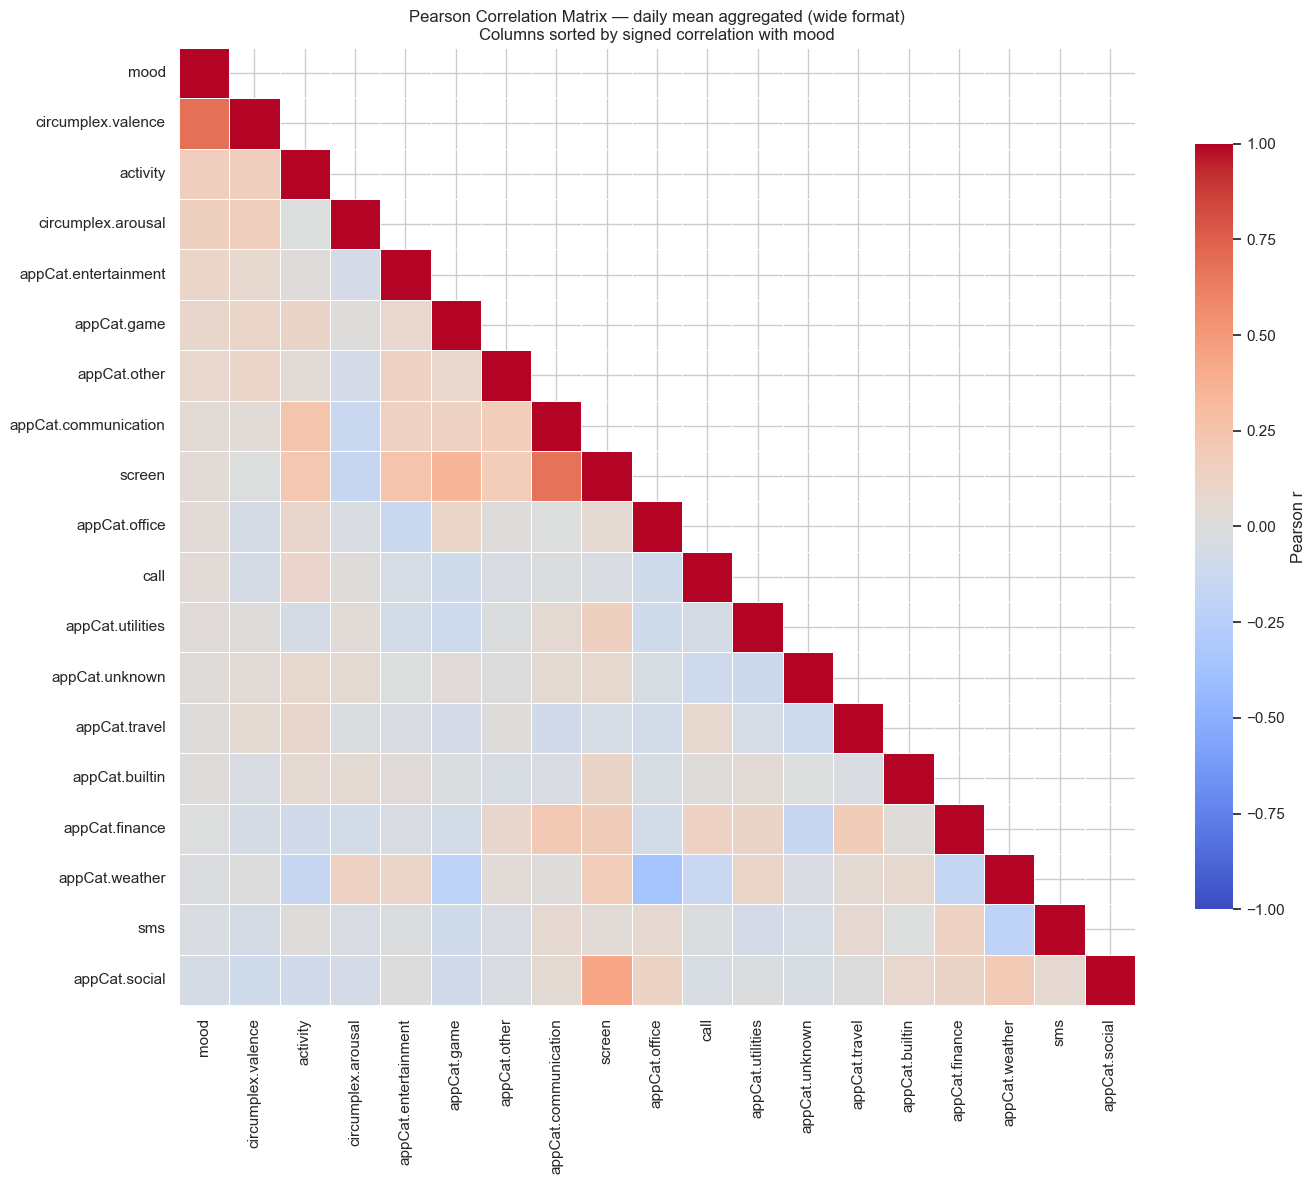

Variables ranked by signed Pearson r with mood:
circumplex.valence      0.685
activity                0.167
circumplex.arousal      0.153
appCat.entertainment    0.107
appCat.game             0.086
appCat.other            0.081
appCat.communication    0.041
screen                  0.039
appCat.office           0.038
call                    0.034
appCat.utilities        0.028
appCat.unknown          0.022
appCat.travel           0.015
appCat.builtin          0.012
appCat.finance         -0.001
appCat.weather         -0.018
sms                    -0.025
appCat.social          -0.061


In [23]:
# --- Plot 6a: Pearson Correlation heatmap — lower triangle only ---
numeric_cols = wide.select_dtypes(include='number').drop(columns=['day_of_week'], errors='ignore').columns.tolist()
corr_pearson = wide[numeric_cols].corr(method='pearson')

# Same column order as Spearman (signed r with mood, descending)
mood_corr_signed = corr_pearson['mood'].drop('mood').sort_values(ascending=False)
col_order = ['mood'] + mood_corr_signed.index.tolist()
corr_pearson_sorted = corr_pearson.loc[col_order, col_order]

mask = np.triu(np.ones_like(corr_pearson_sorted, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_pearson_sorted, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Pearson Correlation Matrix — daily mean aggregated (wide format)\nColumns sorted by signed correlation with mood')
plt.tight_layout()
save_figure('1a_correlation_heatmap_pearson.png')
plt.show()

print('Variables ranked by signed Pearson r with mood:')
print(corr_pearson['mood'].drop('mood').sort_values(ascending=False).round(3).to_string())


**Pearson Correlation Matrix**

Pearson measures linear relationships between variables. It assumes continuous, approximately normally distributed data — an assumption that is violated here (mood is ordinal, appCat variables are zero-inflated and skewed). Use this matrix as a baseline; compare with Spearman below to see where the assumptions matter.

> `is_weekend` (1 = Saturday or Sunday) is a feature that will be engineered in Task 1C. It is not included in these correlation matrices.

Saved: figures/1a_correlation_heatmap.png


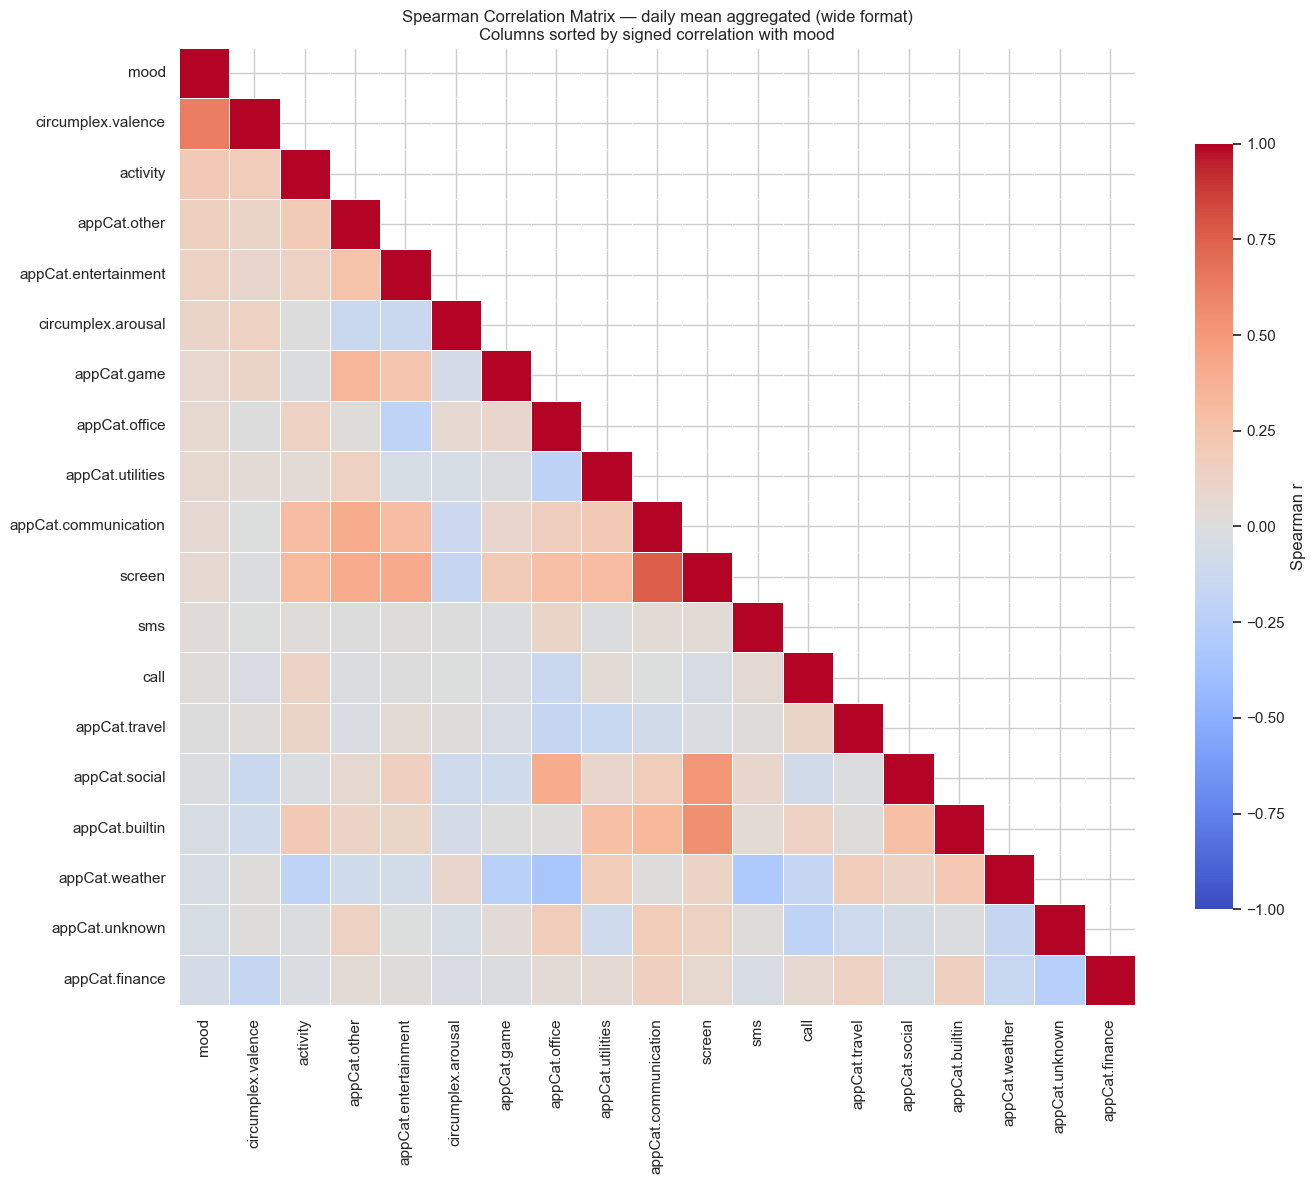

Variables ranked by signed Spearman r with mood:
circumplex.valence      0.631
activity                0.214
appCat.other            0.152
appCat.entertainment    0.147
circumplex.arousal      0.112
appCat.game             0.079
appCat.office           0.077
appCat.utilities        0.074
appCat.communication    0.069
screen                  0.067
sms                     0.026
call                    0.019
appCat.travel           0.006
appCat.social          -0.012
appCat.builtin         -0.039
appCat.weather         -0.042
appCat.unknown         -0.053
appCat.finance         -0.072


In [24]:
# --- Plot 6: Spearman Correlation heatmap — lower triangle only ---
# Spearman is used instead of Pearson: mood is ordinal (1–10 integers),
# appCat.* variables are zero-inflated and heavily skewed — both violate Pearson's assumptions.
# Spearman works on ranks, making it robust to outliers and valid for ordinal/skewed data.
numeric_cols = wide.select_dtypes(include='number').drop(columns=['day_of_week'], errors='ignore').columns.tolist()
corr = wide[numeric_cols].corr(method='spearman')

# Order: mood first, then others sorted by signed correlation with mood (descending)
mood_corr_signed = corr['mood'].drop('mood').sort_values(ascending=False)
col_order = ['mood'] + mood_corr_signed.index.tolist()
corr_sorted = corr.loc[col_order, col_order]

# Lower triangle mask (True = hide)
mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_sorted, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman r'})
ax.set_title('Spearman Correlation Matrix — daily mean aggregated (wide format)\nColumns sorted by signed correlation with mood')
plt.tight_layout()
save_figure('1a_correlation_heatmap.png')
plt.show()

print('Variables ranked by signed Spearman r with mood:')
print(corr['mood'].drop('mood').sort_values(ascending=False).round(3).to_string())


Saved: figures/1a_correlation_diff.png


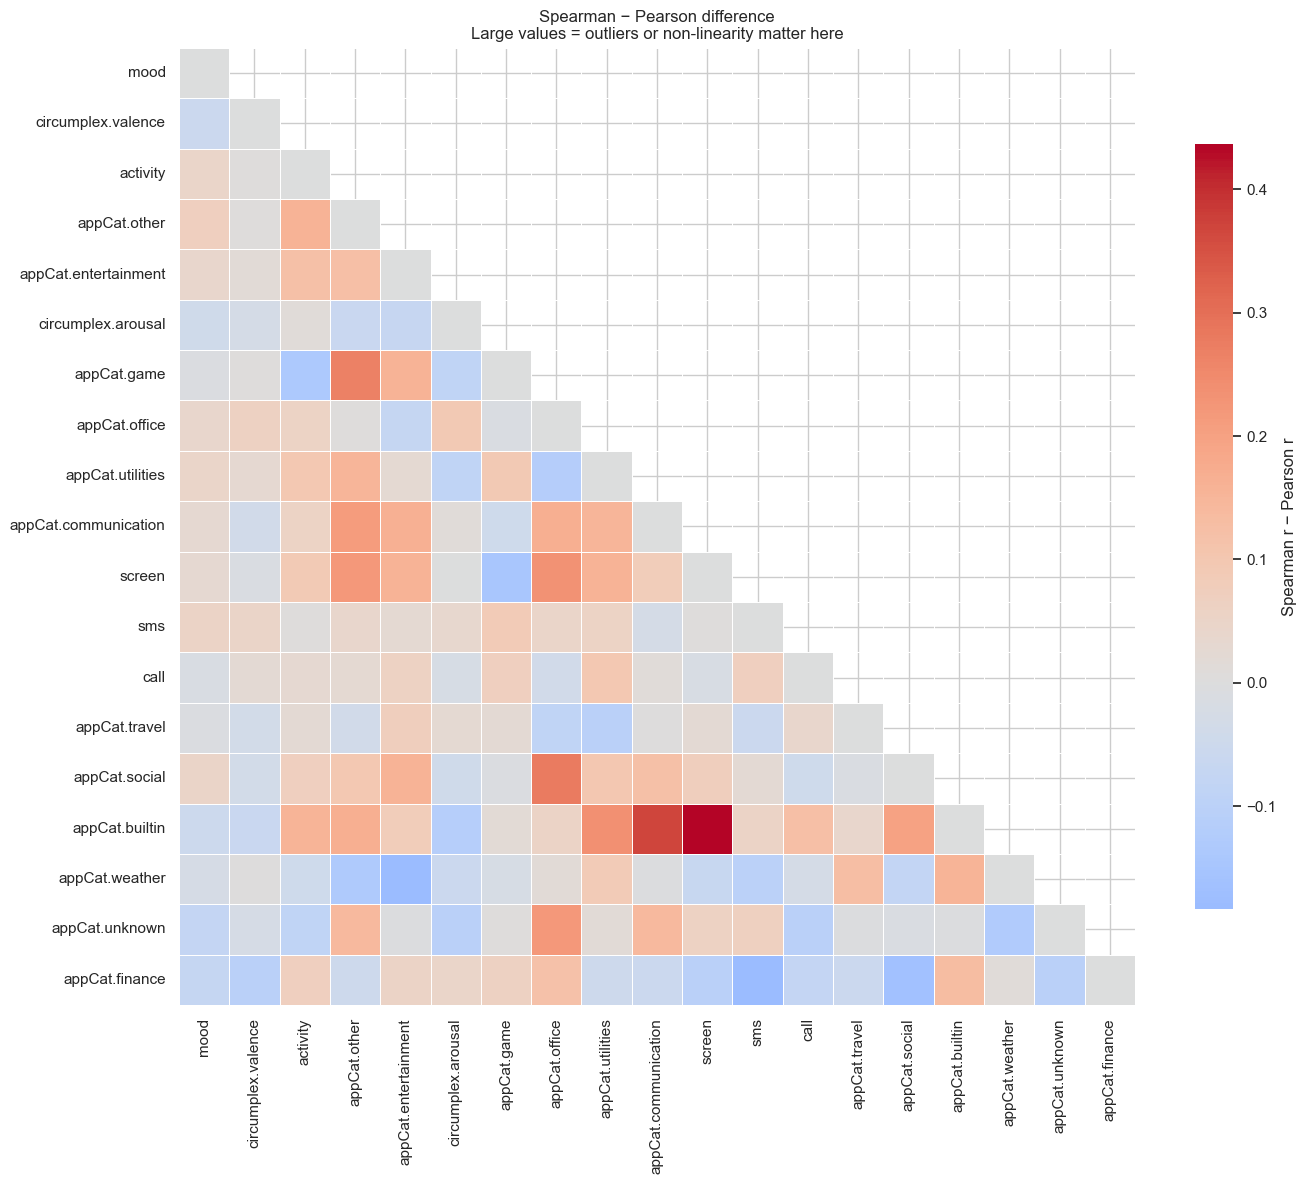

Top 10 pairs where Spearman and Pearson disagree most:
appCat.builtin        screen                  0.437
screen                appCat.builtin          0.437
appCat.communication  appCat.builtin          0.367
appCat.builtin        appCat.communication    0.367
appCat.social         appCat.office           0.278
appCat.office         appCat.social           0.278
appCat.other          appCat.game             0.266
appCat.game           appCat.other            0.266
appCat.utilities      appCat.builtin          0.236
appCat.builtin        appCat.utilities        0.236


In [25]:
# --- Difference heatmap: Spearman minus Pearson — lower triangle only ---
# Cells where the two methods disagree most reveal where outliers or non-linearity matter.
corr_pearson  = wide[numeric_cols].corr(method='pearson')
corr_spearman = wide[numeric_cols].corr(method='spearman')
diff = corr_spearman - corr_pearson

# Recompute col_order here to avoid dependency on cell 43
_mood_corr_diff = corr_spearman['mood'].drop('mood').sort_values(ascending=False)
col_order_diff = ['mood'] + _mood_corr_diff.index.tolist()
diff = diff.loc[col_order_diff, col_order_diff]

# Lower triangle mask (True = hide)
mask_diff = np.triu(np.ones_like(diff, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(diff, mask=mask_diff, cmap='coolwarm', center=0,
            annot=False, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman r − Pearson r'})
ax.set_title('Spearman − Pearson difference\nLarge values = outliers or non-linearity matter here')
plt.tight_layout()
save_figure('1a_correlation_diff.png')
plt.show()

# Print pairs with largest disagreement (excluding diagonal)
mask_vals = np.ones(diff.shape, dtype=bool)
np.fill_diagonal(mask_vals, False)
diff_vals = diff.where(mask_vals).abs().stack().sort_values(ascending=False)
print('Top 10 pairs where Spearman and Pearson disagree most:')
print(diff_vals.head(10).round(3).to_string())

**Spearman − Pearson difference**

Cells close to zero (white) mean both methods agree — the relationship is roughly linear and not distorted by outliers.

Cells with strong colour indicate where the two methods **disagree**:
- **Red (Spearman > Pearson):** Spearman finds a stronger relationship — likely a monotone but non-linear association, or Pearson was being pulled down by zero-heavy distributions.
- **Blue (Pearson > Spearman):** Pearson finds a stronger relationship — likely driven by a few extreme outliers that inflate the linear correlation artificially.

Pairs with large differences are the ones where the choice of metric actually matters for modelling.

**Key findings — correlation analysis (Pearson, Spearman, difference)**

**What correlates with mood:**
- `circumplex.valence` is by far the strongest predictor (see Spearman output above) — feeling positively is directly associated with higher mood, consistent with the 2D circumplex model of emotion
- `activity` shows a moderate positive correlation (see output above) — more physical movement tends to coincide with better mood
- All other variables are weak individually

**App usage and screen time:**
- All `appCat.*` and `screen` show very weak correlations with mood — daily phone usage patterns alone are not strong mood predictors at the individual level
- App categories are moderately inter-correlated with each other, suggesting a general "heavy phone use" factor

**Pearson vs Spearman:**
- Both methods agree on mood-related correlations — the choice of metric does not change conclusions about predictors of mood
- The largest disagreement is in the `appCat.builtin` × `screen` pair (difference matrix, darkest red cell) — Pearson is suppressed there by outliers/non-linearity. These two variables should be treated carefully in modelling
- `appCat.*` variables in general show more divergence between methods, confirming that their skewed, zero-heavy distributions distort Pearson

## 9. Missingness heatmap — which variables are absent, and for whom?

In long format, "missing" means **no row exists** for a (user, date, variable) triple.  
For app-usage variables this almost certainly encodes **zero usage** (the phone was not opened for that category), not unknown data — a critical distinction for imputation.

Saved: figures/1a_missingness_heatmap.png


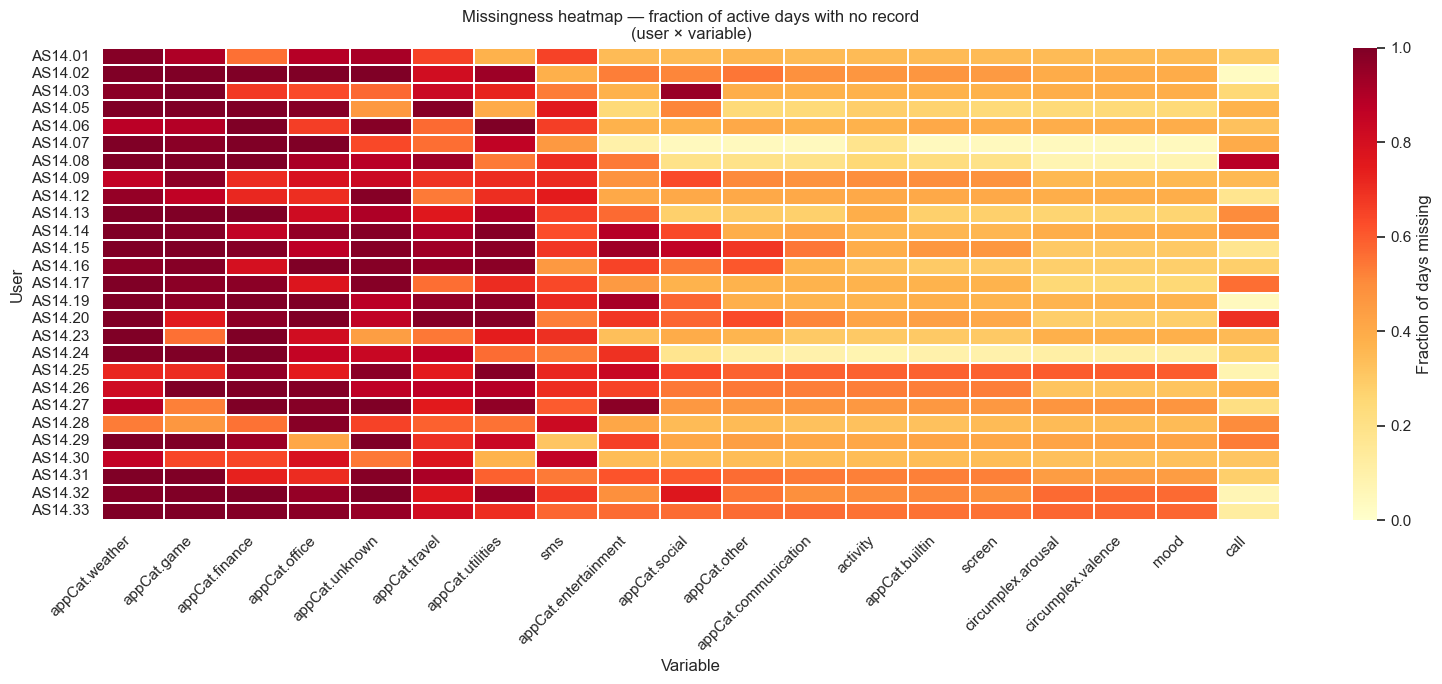

Mean missing fraction per variable:
variable
appCat.weather          0.942
appCat.game             0.896
appCat.finance          0.891
appCat.office           0.859
appCat.unknown          0.856
appCat.travel           0.776
appCat.utilities        0.775
sms                     0.627
appCat.entertainment    0.558
appCat.social           0.484
appCat.other            0.419
appCat.communication    0.387
activity                0.387
appCat.builtin          0.381
screen                  0.375
circumplex.arousal      0.346
circumplex.valence      0.346
mood                    0.346
call                    0.331


In [26]:
# --- Plot 7: Missingness heatmap (variable × user) ---
presence = df.groupby(['id', 'variable'])['date'].nunique().unstack('variable').fillna(0)
n_active  = df.groupby('id')['date'].nunique()
miss_frac = presence.apply(lambda col: 1 - col / n_active).fillna(1)
var_order = miss_frac.mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(miss_frac[var_order], cmap='YlOrRd', vmin=0, vmax=1,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Fraction of days missing'})
ax.set_title('Missingness heatmap — fraction of active days with no record\n(user × variable)')
ax.set_xlabel('Variable'); ax.set_ylabel('User')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_missingness_heatmap.png')
plt.show()

print('Mean missing fraction per variable:')
print(miss_frac.mean().sort_values(ascending=False).round(3).to_string())

**Key findings — missingness:**
- `call` and `sms` appear near the low end of the missingness scale — most participants made calls and sent texts on most active days. Where these variables *are* missing, it genuinely means **no events occurred that day** (zero calls / zero SMS), not a sensor failure
- `appCat.*` variables show highly **variable missingness across users** — some users never use certain categories
- For app categories, a missing row means **zero usage** on that day, not truly absent data; this distinction is critical for imputation in Task 1B (fill with 0, not the mean)
- Some users show **block missingness** (systematic absence for whole periods), suggesting the phone was not carried or the app was uninstalled — these rows must be handled carefully

## 10. Mood autocorrelation — does today's mood predict tomorrow's?

Autocorrelation is computed for lags 1 to 14 days, using both Pearson and Spearman. Only pairs where the gap between days equals exactly the lag are used — this avoids bridging temporal gaps in the data and keeps each lag estimate clean.

Lag- 1: Pearson r = 0.472, Spearman r = 0.477  (n = 1,216)
Lag- 2: Pearson r = 0.394, Spearman r = 0.364  (n = 1,168)
Lag- 3: Pearson r = 0.304, Spearman r = 0.287  (n = 1,127)
Lag- 4: Pearson r = 0.357, Spearman r = 0.334  (n = 1,088)
Lag- 5: Pearson r = 0.360, Spearman r = 0.348  (n = 1,049)
Lag- 6: Pearson r = 0.357, Spearman r = 0.366  (n = 1,010)
Lag- 7: Pearson r = 0.336, Spearman r = 0.368  (n = 973)
Lag- 8: Pearson r = 0.262, Spearman r = 0.292  (n = 936)
Lag- 9: Pearson r = 0.273, Spearman r = 0.251  (n = 899)
Lag-10: Pearson r = 0.233, Spearman r = 0.242  (n = 866)
Lag-11: Pearson r = 0.285, Spearman r = 0.280  (n = 833)
Lag-12: Pearson r = 0.249, Spearman r = 0.272  (n = 801)
Lag-13: Pearson r = 0.296, Spearman r = 0.288  (n = 769)
Lag-14: Pearson r = 0.299, Spearman r = 0.314  (n = 737)
Saved: figures/1a_mood_autocorrelation.png


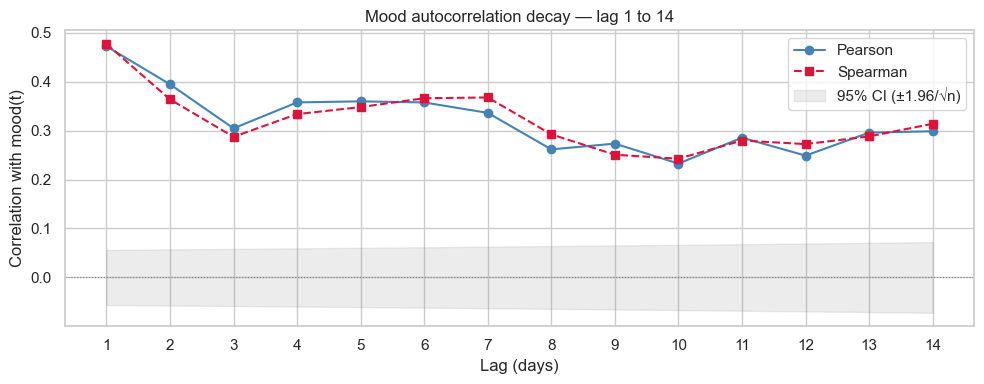

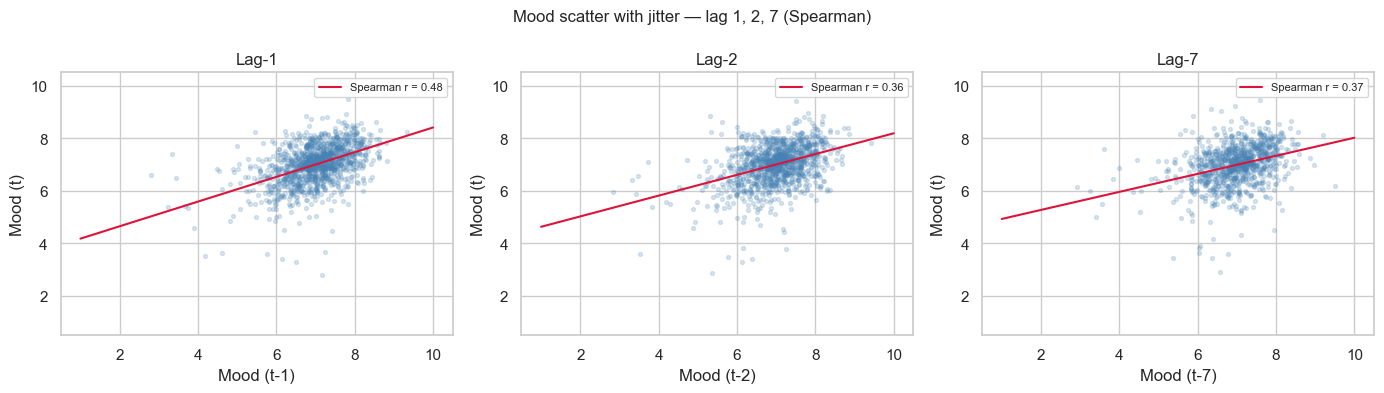

In [27]:
# --- Plot 8: Mood autocorrelation — lag 1 to 14, Spearman + Pearson ---
daily_mood_lag = (df[df['variable'] == 'mood']
                  .groupby(['id', 'date'])['value']
                  .mean()
                  .reset_index()
                  .sort_values(['id', 'date']))

daily_mood_lag['date'] = pd.to_datetime(daily_mood_lag['date'])

results = []
for lag in range(1, 15):
    tmp = daily_mood_lag.copy()
    tmp[f'mood_lag{lag}'] = tmp.groupby('id')['value'].shift(lag)
    tmp['prev_date'] = tmp.groupby('id')['date'].shift(lag)
    tmp['gap_days'] = (tmp['date'] - tmp['prev_date']).dt.days
    tmp = tmp[tmp['gap_days'] == lag].dropna(subset=[f'mood_lag{lag}'])
    r_pearson  = tmp['value'].corr(tmp[f'mood_lag{lag}'], method='pearson')
    r_spearman = tmp['value'].corr(tmp[f'mood_lag{lag}'], method='spearman')
    results.append({'lag': lag, 'n': len(tmp), 'pearson': r_pearson, 'spearman': r_spearman})
    print(f'Lag-{lag:2d}: Pearson r = {r_pearson:.3f}, Spearman r = {r_spearman:.3f}  (n = {len(tmp):,})')

results_df = pd.DataFrame(results)

# --- Decay plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_df['lag'], results_df['pearson'],  marker='o', label='Pearson',  color='steelblue')
ax.plot(results_df['lag'], results_df['spearman'], marker='s', label='Spearman', color='crimson', linestyle='--')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')

# 95% significance bounds: ±1.96 / sqrt(n) per lag
ci = 1.96 / np.sqrt(results_df['n'])
ax.fill_between(results_df['lag'], -ci, ci, alpha=0.15, color='grey', label='95% CI (±1.96/√n)')

ax.set_xlabel('Lag (days)')
ax.set_ylabel('Correlation with mood(t)')
ax.set_title('Mood autocorrelation decay — lag 1 to 14')
ax.set_xticks(range(1, 15))
ax.legend()
plt.tight_layout()
save_figure('1a_mood_autocorrelation.png')
plt.show()

# --- Scatter plots with jitter for lag 1, 2, 7 ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rng = np.random.default_rng(42)
for ax, lag in zip(axes, [1, 2, 7]):
    tmp = daily_mood_lag.copy()
    tmp[f'mood_lag{lag}'] = tmp.groupby('id')['value'].shift(lag)
    tmp['prev_date'] = tmp.groupby('id')['date'].shift(lag)
    tmp['gap_days'] = (tmp['date'] - tmp['prev_date']).dt.days
    tmp = tmp[tmp['gap_days'] == lag].dropna(subset=[f'mood_lag{lag}'])
    r = tmp['value'].corr(tmp[f'mood_lag{lag}'], method='spearman')
    # Add jitter (±0.25) so discrete values don't stack
    x = tmp[f'mood_lag{lag}'] + rng.uniform(-0.25, 0.25, size=len(tmp))
    y = tmp['value']           + rng.uniform(-0.25, 0.25, size=len(tmp))
    ax.scatter(x, y, alpha=0.2, s=8, color='steelblue')
    m, b = np.polyfit(tmp[f'mood_lag{lag}'], tmp['value'], 1)
    x_line = np.linspace(1, 10, 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, label=f'Spearman r = {r:.2f}')
    ax.set_xlabel(f'Mood (t-{lag})')
    ax.set_ylabel('Mood (t)')
    ax.set_title(f'Lag-{lag}')
    ax.set_xlim(0.5, 10.5); ax.set_ylim(0.5, 10.5)
    ax.legend(fontsize=8)
plt.suptitle('Mood scatter with jitter — lag 1, 2, 7 (Spearman)', fontsize=12)
plt.tight_layout()
plt.show()

### 10b. Per-user ACF + PACF — does pooling hide heterogeneity?

The correlations above pool all 27 users. A user whose mood is highly persistent (slow-decaying lag curve) and one whose mood is near-random day-to-day will average out to a single "moderate" decay. If the population is **bimodal** (persistent vs volatile users), a one-size-fits-all window length is wrong — per-user window tuning, or a model that adapts (e.g. LSTM), is preferable.

We also add the **Partial Autocorrelation Function (PACF)**. ACF at lag k is inflated by the chain mood(t)↔mood(t-1)↔…↔mood(t-k); PACF strips that out, so PACF(k) measures the *direct* contribution of lag k once all intermediate lags are controlled for. For feature engineering we keep lag-k only if its PACF is detectably non-zero.

Each user's series is first reindexed to a continuous daily range and linearly interpolated over short internal gaps (consistent with Task 1B), so that ACF/PACF are computed on an evenly-spaced series as required by `statsmodels`.

Saved: figures/1a_mood_acf_pacf_per_user.png


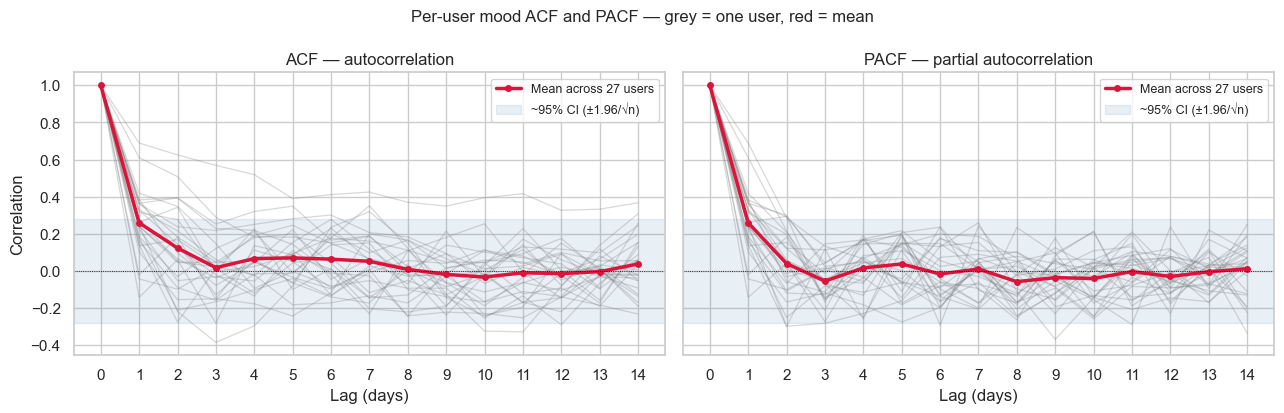

Users retained (>= 25 daily observations after reindex+interp): 27/27

Per-user ACF(lag 1) — spread across users:
count    27.000
mean      0.259
std       0.177
min      -0.142
25%       0.171
50%       0.259
75%       0.364
max       0.689

Mean PACF across users, first 5 lags:
  PACF(lag 1): mean=+0.259  median=+0.259  frac |v|>CI=44%
  PACF(lag 2): mean=+0.040  median=+0.044  frac |v|>CI=22%
  PACF(lag 3): mean=-0.054  median=-0.058  frac |v|>CI=4%
  PACF(lag 4): mean=+0.017  median=+0.048  frac |v|>CI=0%
  PACF(lag 5): mean=+0.038  median=+0.109  frac |v|>CI=0%


In [28]:
# --- Plot 8b: Per-user ACF and PACF — grey = one user, red = mean ---
from statsmodels.tsa.stattools import acf, pacf

MAX_LAG = 14
MIN_OBS = 25  # need at least this many days for a stable per-user estimate

per_user_acf, per_user_pacf, kept_users, series_lengths = [], [], [], []
for uid, grp in daily_mood_lag.groupby('id'):
    s = (grp.sort_values('date')
            .set_index('date')['value'])
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='D')
    s_filled = s.reindex(full_idx).interpolate(method='linear').dropna()
    if len(s_filled) < MIN_OBS:
        continue
    per_user_acf.append(acf(s_filled.to_numpy(), nlags=MAX_LAG, fft=False))
    per_user_pacf.append(pacf(s_filled.to_numpy(), nlags=MAX_LAG, method='ywm'))
    kept_users.append(uid)
    series_lengths.append(len(s_filled))

per_user_acf = np.vstack(per_user_acf)
per_user_pacf = np.vstack(per_user_pacf)
mean_acf  = per_user_acf.mean(axis=0)
mean_pacf = per_user_pacf.mean(axis=0)

# Approximate 95% significance band: ±1.96/sqrt(N_avg) (Bartlett's bound)
ci = 1.96 / np.sqrt(np.mean(series_lengths))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
lags = np.arange(MAX_LAG + 1)

for ax, mat, mean_vals, title in [
    (axes[0], per_user_acf,  mean_acf,  'ACF — autocorrelation'),
    (axes[1], per_user_pacf, mean_pacf, 'PACF — partial autocorrelation'),
]:
    for row in mat:
        ax.plot(lags, row, color='grey', alpha=0.3, linewidth=0.9)
    ax.plot(lags, mean_vals, color='crimson', linewidth=2.5, marker='o', markersize=4,
            label=f'Mean across {mat.shape[0]} users')
    ax.axhspan(-ci, ci, alpha=0.12, color='steelblue', label='~95% CI (±1.96/√n)')
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_xlabel('Lag (days)')
    ax.set_xticks(lags)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_ylabel('Correlation')
plt.suptitle('Per-user mood ACF and PACF — grey = one user, red = mean', fontsize=12)
plt.tight_layout()
save_figure('1a_mood_acf_pacf_per_user.png')
plt.show()

# --- Summary: heterogeneity at lag-1, and which lags survive in PACF ---
print(f'Users retained (>= {MIN_OBS} daily observations after reindex+interp): {len(kept_users)}/27')
print()
print('Per-user ACF(lag 1) — spread across users:')
print(pd.Series(per_user_acf[:, 1]).describe().round(3).to_string())
print()
print('Mean PACF across users, first 5 lags:')
for lag in range(1, 6):
    vals = per_user_pacf[:, lag]
    frac_signif = np.mean(np.abs(vals) > ci)
    print(f'  PACF(lag {lag}): mean={vals.mean():+.3f}  median={np.median(vals):+.3f}  '
          f'frac |v|>CI={frac_signif:.0%}')


**Key findings — mood autocorrelation (lag 1–14)**

- **Lag-1 is the strongest predictor** — yesterday's mood is the single best predictor of today's mood, and this holds in both the pooled and per-user views
- **Correlation decays gradually** with increasing lag but the pooled curve stays above the 95% CI band for most lags
- **Pearson and Spearman agree closely** across all lags — the autocorrelation structure is robust to the choice of metric

**Per-user overlay (§10b):** the pooled ACF hides real heterogeneity. Per-user ACF(lag 1) spans from **−0.14 to +0.69** (IQR 0.17–0.36) — some users are persistent, others are near-random day-to-day, and at least one shows weakly *negative* lag-1 (bounces back). A single global window length is a compromise; models that adapt per user (LSTM, per-user feature normalisation) have a real motivation here, not just a hand-wave.

**PACF implication for feature engineering:** PACF(lag 1) is consistently the only lag with clear signal — mean ≈ **+0.26**, significant in **44%** of users. PACF(lag 2) drops to ≈ **+0.04** (significant in 22%), and PACF(lag ≥ 3) sits inside the ±1.96/√n band for essentially everyone. Higher-lag ACF correlations are therefore largely *indirect*, inherited through the lag-1 chain.

**Keep lag-1 mood as mandatory, lag-2 as optional, and avoid bloating the feature set with lag-3+.** For longer-range information, a rolling 7-day *summary* (mean, std, trend) is a better signal than raw lag-k values.

## 11. Inter-subject variability — do users differ in baseline mood?

Saved: figures/1a_inter_subject_variability.png


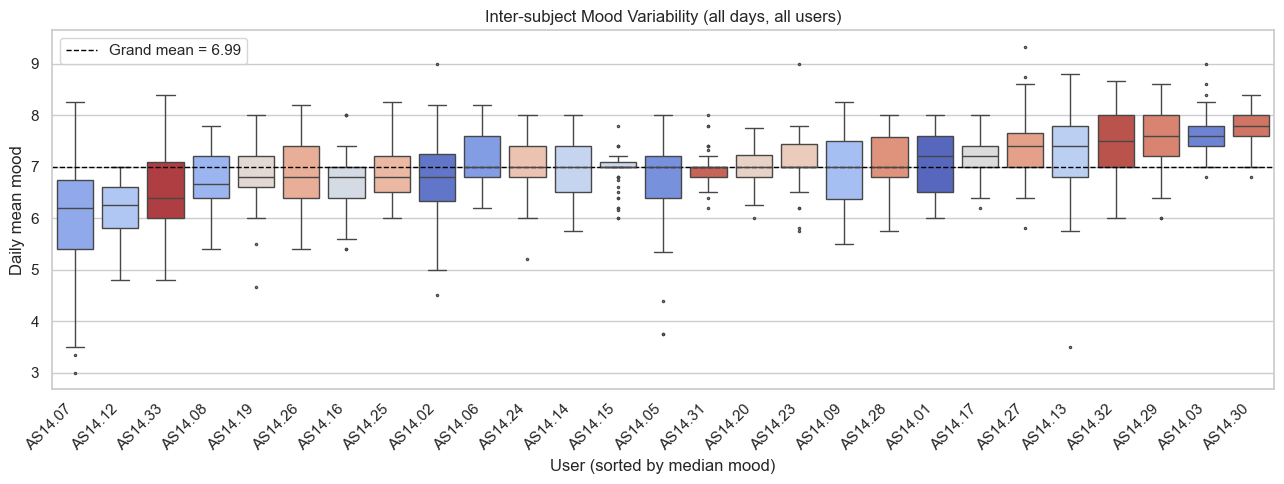

Per-user statistics:
         median   std
id                   
AS14.07    6.20  1.17
AS14.12    6.25  0.53
AS14.33    6.40  0.87
AS14.08    6.67  0.55
AS14.19    6.80  0.60
AS14.26    6.80  0.66
AS14.16    6.80  0.60
AS14.25    6.80  0.57
AS14.02    6.80  0.86
AS14.06    7.00  0.52
AS14.24    7.00  0.54
AS14.14    7.00  0.63
AS14.15    7.00  0.35
AS14.05    7.00  0.86
AS14.31    7.00  0.35
AS14.20    7.00  0.38
AS14.23    7.00  0.58
AS14.09    7.00  0.68
AS14.28    7.00  0.62
AS14.01    7.20  0.60
AS14.17    7.20  0.36
AS14.27    7.40  0.64
AS14.13    7.40  0.91
AS14.32    7.50  0.65
AS14.29    7.60  0.60
AS14.03    7.60  0.42
AS14.30    7.80  0.30


In [29]:
# --- Plot 9: Inter-subject mood variability ---
user_mood_daily = df[df['variable'] == 'mood'].groupby(['id', 'date'])['value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
user_order = user_mood_daily.groupby('id')['value'].median().sort_values().index
sns.boxplot(data=user_mood_daily, x='id', y='value', order=user_order, ax=ax,
            hue='id', palette='coolwarm', legend=False,
            flierprops=dict(marker='.', markersize=3))
grand_mean = user_mood_daily['value'].mean()
ax.axhline(grand_mean, color='black', linestyle='--',
           linewidth=1, label=f'Grand mean = {grand_mean:.2f}')
ax.set_xlabel('User (sorted by median mood)')
ax.set_ylabel('Daily mean mood')
ax.set_title('Inter-subject Mood Variability (all days, all users)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_inter_subject_variability.png')
plt.show()

print('Per-user statistics:')
print(user_mood_daily.groupby('id')['value'].agg(['median', 'std']).round(2).sort_values('median'))


**Key findings — inter-subject variability:**
- User baseline moods span roughly **3.5 – 8.0** (median per user), a range larger than the intra-user fluctuation for many participants
- This large between-subject heterogeneity justifies adding **user-level mean mood** as a feature, or training **personalised models** per user
- Users with consistently low or high baselines will bias a global model; standardising per-user (z-scoring) before training may help

## 12. Signal checks — sparse app-categories, weekend effect, circumplex model

**A — Sparse app-category variables:**
- Several `appCat.*` columns will have ≥ 95 % zero values — nearly useless as raw features; need **log(1 + x)** transformation or aggregation

**B — Weekend effect:**
- A significant difference between weekday and weekend mood justifies adding an `is_weekend` binary flag (to be created in Task 1C)

**C — Circumplex model check:**
- `circumplex.valence` should show the strongest positive correlation with mood; `circumplex.arousal` may be near-zero or weakly negative

Zero-usage fraction per app category (user-days):
appCat.weather          0.943
appCat.game             0.902
appCat.finance          0.895
appCat.unknown          0.866
appCat.office           0.860
appCat.travel           0.783
appCat.utilities        0.781
appCat.entertainment    0.569
appCat.social           0.499
appCat.other            0.432
appCat.communication    0.400
appCat.builtin          0.394

Variables with ≥95 % zero usage: []

Weekend vs weekday mood:
  Weekday mean: 6.940  |  Weekend mean: 7.114
  Mann-Whitney U test: U=139152, p=0.0000

Circumplex correlations with mood (Spearman, on complete rows only):
  Mood ↔ arousal : r = 0.114
  Mood ↔ valence : r = 0.631


Saved: figures/1a_circumplex.png


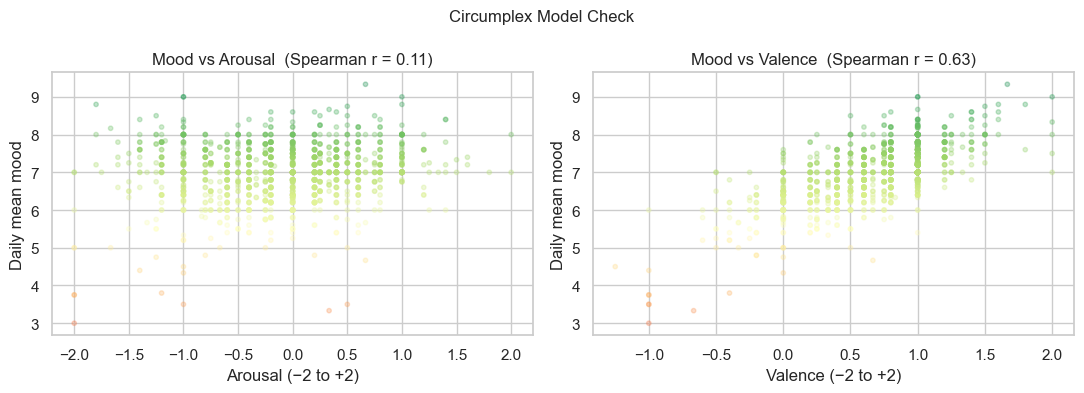

In [30]:
from scipy import stats as scipy_stats

# ── A. Sparse app-category variables ──────────────────────────────────────────
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat.')]
wide_app_cols = [v for v in app_vars if v in wide.columns]
zero_frac = (wide[wide_app_cols].fillna(0) == 0).mean().sort_values(ascending=False)

print('Zero-usage fraction per app category (user-days):')
print(zero_frac.round(3).to_string())
sparse_95 = zero_frac[zero_frac >= 0.95].index.tolist()
print(f'\nVariables with ≥95 % zero usage: {sparse_95}')

# ── B. Weekend effect ─────────────────────────────────────────────────────────
# is_weekend is not a column in `wide` yet (created in Task 1C);
# compute the mask locally here for the EDA check only.
is_weekend_mask = wide['date'].dt.dayofweek >= 5
weekday_mood = wide[~is_weekend_mask]['mood'].dropna()
weekend_mood = wide[is_weekend_mask]['mood'].dropna()
# Mann-Whitney U is used instead of t-test: mood is ordinal (1–10 integers),
# so a non-parametric test is more appropriate.
u_stat, p_val = scipy_stats.mannwhitneyu(weekday_mood, weekend_mood, alternative='two-sided')
print(f'\nWeekend vs weekday mood:')
print(f'  Weekday mean: {weekday_mood.mean():.3f}  |  Weekend mean: {weekend_mood.mean():.3f}')
print(f'  Mann-Whitney U test: U={u_stat:.0f}, p={p_val:.4f}')

# ── C. Circumplex model (arousal × valence → mood) ───────────────────────────
circ_cols = ['mood', 'circumplex.arousal', 'circumplex.valence']
circumplex = wide[circ_cols].dropna()
# Spearman used for consistency with the rest of the notebook (ordinal mood)
r_arousal = circumplex['mood'].corr(circumplex['circumplex.arousal'], method='spearman')
r_valence = circumplex['mood'].corr(circumplex['circumplex.valence'], method='spearman')
print(f'\nCircumplex correlations with mood (Spearman, on complete rows only):')
print(f'  Mood ↔ arousal : r = {r_arousal:.3f}')
print(f'  Mood ↔ valence : r = {r_valence:.3f}')

# ── D. Circumplex scatter ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, r, label in zip(axes,
                              ['circumplex.arousal', 'circumplex.valence'],
                              [r_arousal, r_valence],
                              ['Arousal', 'Valence']):
    sc = ax.scatter(circumplex[col], circumplex['mood'],
                    alpha=0.3, s=10, c=circumplex['mood'],
                    cmap='RdYlGn', vmin=1, vmax=10)
    ax.set_xlabel(f'{label} (−2 to +2)')
    ax.set_ylabel('Daily mean mood')
    ax.set_title(f'Mood vs {label}  (Spearman r = {r:.2f})')
plt.suptitle('Circumplex Model Check', fontsize=12)
plt.tight_layout()
save_figure('1a_circumplex.png')
plt.show()

**Key findings — signal checks**

- **App sparsity:** no variable exceeds 95% zeros, so none needs to be dropped outright. However, `appCat.weather`, `appCat.game`, and `appCat.finance` are heavily sparse (see output above) — a `log(1+x)` transformation is required before modelling to avoid these variables being dominated by their rare high values.
- **Weekend effect:** mood is slightly but significantly higher on weekends (see output above for exact values). A Mann-Whitney U test is used in place of a t-test because mood is ordinal (1–10 integers) — the parametric t-test assumption of normality does not hold. The effect is small in magnitude but consistent — add `is_weekend` as a binary feature.
- **Circumplex model confirmed (Spearman):** `circumplex.valence` correlates strongly with mood while `circumplex.arousal` is weak (see output above), exactly as the psychological theory predicts. The data is consistent with the 2D emotion model — both dimensions should be retained as features. Note: the Spearman r here is computed on the subset of user-days where both arousal and valence are recorded, so it may differ slightly from the heatmap value.

---
## EDA Summary — key takeaways

### Data structure
- Long format, 19 variables, 27 users, ~376k rows → wide-format pivot (user-day rows) required before any modelling
- Study ran Feb–Jun 2014; most data concentrated in **March–April**. Drop-off is due to participant attrition, not reduced engagement — active users logged consistently throughout

### Mood (target variable)
- **Goal: predict next-day mood** (daily mean of all mood readings for that day)
- Logged **4–5 times per day** via fixed prompts → target = daily mean mood
- Distribution is **left-skewed**: mass at 6–8, very few low values → class imbalance for classification tasks; threshold should be computed on the **daily-mean distribution**, not on individual readings
- Strong **lag-1 autocorrelation** (see §10) — today's mood is the best single predictor of tomorrow's; lagged mood must be included as a feature
- **PACF** (§10b) shows lag-1 is the only direct signal (mean +0.26); lag-2 is marginal (+0.04) and lag-3+ are noise — add lag-1 mandatorily, lag-2 optionally, and capture longer history via a rolling 7-day summary rather than raw lag-k
- Per-user ACF overlay (§10b) reveals strong heterogeneity (lag-1 ranges −0.14 to +0.69 across users) — motivates per-user normalisation or adaptive (LSTM) models

### Inter-user variability
- User median moods span **~3.5 to 8.0** — between-user differences are larger than within-user fluctuations for many participants
- Active days range from **50 to 101**, with up to **28% missing days** per user → sliding windows must respect temporal gaps
- Per-user mean mood should be added as a feature, or models should be normalised per user

### Predictors
- `circumplex.valence` is the strongest correlate with mood (Spearman r — see §8 output) → retain as primary feature
- `activity` has moderate positive correlation (see §8 output) → useful feature
- All `appCat.*` and `screen` show weak individual correlation with mood — may contribute in combination

### Data quality & preprocessing implications
- `appCat.builtin` contains **negative values** (min ≈ −82k seconds) → likely logging errors, clip to 0 in Task 1B
- `appCat.*` missingness means **zero usage**, not unknown → impute with 0, not mean
- Several `appCat.*` are heavily sparse → consider `log(1+x)` transform or aggregation before modelling
- Pearson is distorted by outliers in skewed variables → **Spearman** is the appropriate correlation metric for this dataset